# MASTER THESIS - model V4 summer V4

It includes g simulation

This notebook demonstrates the usage of the `DarkGreyBox` models via fitting them with `DarkGreyFit`

Model V3 --> this model is using the TiTmCn3R2C grey-box model on a summer period (1st of September to 15th of September) where there is no heating at all

## Importation

In [1]:
import sys
import importlib
from pathlib import Path
import pvlib
from scipy.interpolate import BSpline

# go from ...\docs\tutorials up two levels to the repo root (...\darkgreybox)
repo_root = Path.cwd().parents[1]
sys.path.insert(0, str(repo_root))
importlib.invalidate_caches()


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold
from statsmodels.graphics.tsaplots import plot_pacf

from darkgreybox.models import TiTmCn2R2C_summer_V9
from darkgreybox.night_ventilation import simulate_night_vent_scenario, comfort_metrics
from darkgreybox.fit import darkgreyfit
from docs.tutorials.util.plot import plot
from docs.tutorials.util.error import rmse

2026-03-05 18:06:02,463 darkgreybox  INFO     Logging enabled...


Our temporal resolution is 5 minutes

In [2]:
# the duration of a record (in h - 5 minutes)
rec_duration = 5/60

## Data Loading and Preprocessing

The data is loaded from the CSV file 'data_summer' and processed to extract relevant variables for the thermal model.

In [3]:
def add_bspline_features(df, n_knots=6, degree=3):
    """Add B-spline basis functions using datetime index."""
    # Extract hour of day from the index (assuming it's datetime)
    hour_of_day = df.index.hour + df.index.minute / 60
    
    # Knots from 6am to 8pm
    knots_interior = np.linspace(6, 20, n_knots)
    knots = np.concatenate([
        [knots_interior[0]] * (degree + 1),
        knots_interior,
        [knots_interior[-1]] * (degree + 1)
    ])
    
    n_basis = len(knots) - degree - 1
    
    for i in range(n_basis):
        coef = np.zeros(n_basis)
        coef[i] = 1.0
        bspline = BSpline(knots, coef, degree)
        df[f'bs_{i}'] = bspline(hour_of_day)
    
    return df, n_basis

In [4]:
input_df = pd.read_csv('./data/data_summer_neighbor.csv', index_col=0, parse_dates=True)

input_df['Ti'] = input_df['R01_06_TRU01']
input_df['qv'] = input_df['R01_06_FCI01']
input_df['c'] = input_df['R01_06_CO201']  # Use processed CO2 column
input_df['Ta'] = input_df['HTR9_VES01_TUD01']
input_df['Ik'] = input_df['HTR9_VES01_SI01']
input_df['Tsup'] = input_df['HTRK_VEN01_SpTI01_C']
input_df['theta_z'] = input_df['HTR9_VES01_AZ01']
input_df['gamma_s'] = input_df['HTR9_VES01_SV01']
input_df['T_neigh_1'] = input_df['R01_02_TRU01']
input_df['T_neigh_2'] = input_df['R01_07_TRU01']


# Set initial conditions
input_df['Ti0'] = input_df['Ti'].iloc[0]
input_df['Tm0'] = input_df['Ti'].iloc[0]
input_df['c0'] = input_df['c'].iloc[0]
input_df['N0'] = 0 #We suppose no one in the room at the beginning


input_X = input_df[['qv', 'c', 'Ta', 'Ik', 'Tsup', 'theta_z', 'gamma_s', 'Ti0', 'Tm0', 'c0', 'N0', 'T_neigh_1', 'T_neigh_2']]
input_y = input_df['Ti']


print(f'Input X shape: {input_X.shape}, input y shape: {input_y.shape}')

Input X shape: (4296, 13), input y shape: (4296,)


## Data Splitting

Initial conditions are set for the state variables at t=0, using the first measurements from the dataset. The data is then split into training (80%) and test (20%) sets for model validation.
`shuffle=False` to preserve the temporal order of the time series data. This is important for thermal modeling where historical context matters.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(input_X, input_y, test_size=0.2, shuffle=False)

print(f'Train: X shape: {X_train.shape}, y shape: {y_train.shape}')
print(f'Test: X shape: {X_test.shape}, y shape: {y_test.shape}')

# Before training:
X_train, n_bsplines = add_bspline_features(X_train)
X_test, _ = add_bspline_features(X_test)
print(f"Created {n_bsplines} B-spline basis functions")

Train: X shape: (3436, 13), y shape: (3436,)
Test: X shape: (860, 13), y shape: (860,)
Created 10 B-spline basis functions


## Model Training Parameters and Physical Constants

The parameter ranges are carefully chosen to reflect realistic physical bounds and to ensure the optimizer does not hit artificial limits during fitting. Capacitances and resistances are estimated from building material properties and geometry, while internal gains and constants are set according to typical values found in literature or building standards. This approach balances physical realism with flexibility for model calibration.

In [26]:
S_room = 11                             #Surface of the room, found on Revit (m²)
A_windows = 5.48                        #Window area found on Revit (m²)
H_room = 2.7                            #Height of the room (m)
V_room = S_room * H_room                #Volume of the room (m³)
orientation = 270                       # West orientation in degrees

A_neigh_1 = 4*H_room                    # Surface of the neighbor wall 1 (m²) - estimated based on Revit
A_neigh_2 = 4*H_room                    # Surface of the neighbor wall 2 (m²) - estimated based on Revit
U_interior_wall = 1.8                   # U-value of interior walls (W/m²K) - single gypsum board + metal stud 

Rneih_1_i = 1/(U_interior_wall*A_neigh_1)
Rneih_2_i = 1/(U_interior_wall*A_neigh_2)


# Capacitances initial guesses
# C=ρ×V×c_p [J/K] (ρ density kg/m³, V volume m³, c_p specific heat capacity J/kgK)
rho_air_init = 1.2          # kg/m³
cp_air_init = 1005          # J/kgK
rho_furn_init = 500         # kg/m³
cp_furn_init = 1200         # J/kgK
V_furn_init = 0.1 * V_room  # m³  (10% of room volume as furniture/contents volume)
Ci_i = rho_air_init * V_room * cp_air_init + rho_furn_init * V_furn_init * cp_furn_init

rho_wall = 2200             # kg/m³
cp_conc  = 840              # J/kgK
wall_thickness = 0.1        # m
Cm_i = rho_wall * (S_room * wall_thickness) * cp_conc  



# Resistances initial guesses
# R=1/(U*A) or 1/(h*A) [K/W]
h_conv = 8                     # W/m²K
S_int_mass = 0.6 * S_room      # internal surfaces area ~60%
Rim_i = 1 / (h_conv * S_int_mass)

U_env = 0.25                   # W/m²K
Rout_i= 1 / (U_env * S_room)


# Capacitances and resistances variation ranges
# WIDENED based on optimizer hitting bounds (see diagnostic cell)
Ci_min = 0.05*Ci_i      # Was 0.2x → lowered (optimizer wanted smaller)
Ci_max = 2*Ci_i         # Keep similar
Cm_min = 0.1*Cm_i       # Was 0.5x → lowered (optimizer wanted smaller)
Cm_max = 3*Cm_i         # Keep similar

Rim_min = 0.2*Rim_i     # Slightly lower
Rim_max = 2*Rim_i       # Keep similar
Rout_min = 0.1*Rout_i   # Was 0.5x → lowered (optimizer wanted more heat loss)
Rout_max = 2*Rout_i     # Keep similar



# Define training parameters
train_params_TiTmCn2R2C_summer_V4 = {
    'Ti0': {'value': input_df.iloc[0]['Ti0'], 'vary': False},               # Initial indoor temperature
    'Tm0': {'value': input_df.iloc[0]['Tm0'], 'vary': False},               # Initial thermal mass temperature
    'c0': {'value': input_df.iloc[0]['c0'], 'vary': False},                 # Initial CO2 concentration
    'N0': {'value': input_df.iloc[0]['N0'], 'vary': False},                 # Initial number of occupants
    
    #'Ci': {'value': Ci_i, 'vary': True, 'min': Ci_min, 'max': Ci_max},      # Air + light internal components heat capacity at air node (fast mass at Ti)
    #'Cm': {'value': Cm_i, 'vary': True, 'min': Cm_min, 'max': Cm_max},      # Thermal mass heat capacity (heavy structural mass at Tm)
    #'Rim': {'value': Rim_i, 'vary': True, 'min': Rim_min, 'max': Rim_max},  # Thermal resistance indoor air ↔ thermal mass (heat air ↔ building structure)
    #'Rout': {'value': Rout_i, 'vary': True, 'min': Rout_min, 'max': Rout_max},  # Overall thermal resistance indoor air ↔ ambient/outdoor air (heat loss path)
    'Ci': {'value': 1000.19534, 'vary': True, 'min': 1000, 'max': 10000},
    'Cm': {'value': 4167.99849, 'vary': True, 'min': 1000, 'max': 50000},    # Bigger mass\n",
    'Rim': {'value': 0.00153473, 'vary': True, 'min': 0.001, 'max': 0.01},           # Mass-air  \n",
    'Rout': {'value': 0.08885421, 'vary': True, 'min': 0.01, 'max': 1},         # Envelope\n",
    'q_pers': {'value': 75, 'vary': False},                                 # Internal gains per person
    'q_equip_var': {'value': 80, 'vary': False},                            # Variable equipment gains per person
    'q_equip_const': {'value': 10, 'vary': False},                          # Constant equipment gains
    'V': {'value': S_room*H_room, 'vary': False},                           # Volume of the room
    'S': {'value': S_room, 'vary': False},                                  # Surface of the room
    'A': {'value': A_windows, 'vary': False},                               # Window area
    'G': {'value': 0.016, 'vary': False},                                   # Global radiation factor
    'c_out': {'value': 400, 'vary': False},                                 # Outdoor CO2 concentration
    'rho_air': {'value': 1.2, 'vary': False},                               # Air density
    'cp_air': {'value': 1000, 'vary': False},                               # Specific heat capacity of air
    #'g': {'value': 0.55, 'vary': False},                                    # total solar energy transmittance of the glazing 
    'alpha': {'value': 0.1, 'vary': True, 'min': 0.01, 'max': 0.5},         # CO2 occupancy filter parameter
    'gamma_g': {'value': orientation, 'vary': False},                    # glazing angle for IAM calculation
    'n': {'value': 1.526, 'vary': False},                                        # refractive index for IAM calculation
    'K': {'value': 4, 'vary': False},                                   # absorption coefficient for IAM calculation (1/m)
    'L': {'value': 0.003, 'vary': False},                                     # glazing thickness for IAM calculation (m)
    'Rneigh_1': {'value': Rneih_1_i, 'vary': True, 'min': Rneih_1_i*0.1, 'max': Rneih_1_i*10},         # Thermal resistance between the room and the neighboring spaces (simplified representation of heat transfer through internal walls)
    'Rneigh_2': {'value': Rneih_2_i, 'vary': True, 'min': Rneih_2_i*0.1, 'max': Rneih_2_i*10},         # Thermal resistance between the room and the neighboring spaces (simplified representation of heat transfer through internal walls)
    'f_sol': {'value': 0.4, 'vary': True, 'min': 0, 'max': 1},         # Solar gains distribution factor (fraction of solar gains directly affecting indoor air node)
    # 10 B-spline coefficients
    'phi_a': {'value': 0.7, 'vary': True, 'min': 0, 'max': 1},
    'phi_b': {'value': 0.7, 'vary': True, 'min': 0, 'max': 1},
    'phi_c': {'value': 0.7, 'vary': True, 'min': 0, 'max': 1},
    'phi_d': {'value': 0.7, 'vary': True, 'min': 0, 'max': 1},
    'phi_e': {'value': 0.7, 'vary': True, 'min': 0, 'max': 1},
    'phi_f': {'value': 0.7, 'vary': True, 'min': 0, 'max': 1},
    'phi_g': {'value': 0.7, 'vary': True, 'min': 0, 'max': 1},  
    'phi_h': {'value': 0.7, 'vary': True, 'min': 0, 'max': 1},
    'phi_i': {'value': 0.7, 'vary': True, 'min': 0, 'max': 1},
    'phi_j': {'value': 0.7, 'vary': True, 'min': 0, 'max': 1},
}

# Verify stability
print(f"dt = {rec_duration:.4f} hours ({rec_duration * 60:.2f} minutes)")

dt = 0.0833 hours (5.00 minutes)


### 1: Initial conditions
Set up our initial conditions parameters map for testing

### 2: Error metric
To evaluate the performance of our models we will need to define an error metric. Again, there is a wide range of options available from `sklearn`

### 3: Fit method
Under the hood, `DarkGreyBox` uses `lmfit.minimize` to fit the thermal model parameters to the training data by passing it a custom objective function defined by the model class. The fit method used by `lmfit.minimize` can be customised as well. The standard Nelder-Mead and Levenberg-Marquardt methods work well in general. Here we use the Nelder-Mead method.

### 4: Choice of the model

In [27]:
ic_params_map = {
    'Ti0': lambda _X_test, y_test, _train_result: y_test.iloc[0],
    'Tm0': lambda X_test, _y_test, train_result: train_result.var['Tm'][-1] if 'Tm' in train_result.var else X_test.iloc[0]['Tm0'],
    'c0': lambda X_test, _y_test, train_result: train_result.var['c'][-1] if 'c' in train_result.var else X_test.iloc[0]['c0'],
    'N0': lambda X_test, _y_test, train_result: train_result.var['N'][-1] if 'N' in train_result.var else X_test.iloc[0]['N0'],
}

error_metric = rmse

method = 'nelder'

models = [TiTmCn2R2C_summer_V9(train_params_TiTmCn2R2C_summer_V4, rec_duration)]

Now, it is time to run the simulation:

In [28]:
# Run the darkgreyfit
df = darkgreyfit(
    models=models,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    ic_params_map=ic_params_map,
    error_metric=error_metric,
    prefit_filter=None,
    prefit_splits=None,
    method=method,
    n_jobs=1
)

print("Fitting complete!")
print(f"DataFrame shape: {df.shape}")

df

model = df.iloc[0][('train', 'model')]
train_results = df.iloc[0][('train', 'model_result')]
test_results = df.iloc[0][('test', 'model_result')]

# Display model parameters safely
if hasattr(model, "result") and hasattr(model.result, "params"):
    display(model.result.params)
else:
    print("Model parameters not available.")

# Print initial, real initial guess (used in fit), and estimated R and C values
# Initial parameter guesses (from physical calculations)
try:
    init_params = {
        'Ci': {'value': Ci_i},
        'Cm': {'value': Cm_i},
        'Rim': {'value': Rim_i},
        'Rout': {'value': Rout_i}
    }
except NameError:
    # If any of the variables are not defined, set to None
    init_params = {
        'Ci': {'value': None},
        'Cm': {'value': None},
        'Rim': {'value': None},
        'Rout': {'value': None}
    }

# Real initial guess used in fit (from train_params_TiTmCn2R2C_summer)
real_init_params = {}
for key in ['Ci', 'Cm', 'Rim', 'Rout']:
    try:
        real_init_params[key] = train_params_TiTmCn2R2C_summer_V2[key]['value']
    except Exception:
        real_init_params[key] = None

if hasattr(model, "result") and hasattr(model.result, "params"):
    est_params = model.result.params
    print("Parameter   | Initial Guess (calc) | Real Initial Guess (used) | Estimated Value")
    print("--------------------------------------------------------------------------")
    for key in ['Ci', 'Cm', 'Rim', 'Rout']:
        init_val = init_params[key]['value']
        real_init_val = real_init_params[key]
        est_val = est_params[key].value if key in est_params else None
        if init_val is not None and real_init_val is not None and est_val is not None:
            print(f"{key:10} | {init_val:18.4f} | {real_init_val:23.4f} | {est_val:15.4f}")
        elif init_val is not None and real_init_val is not None:
            print(f"{key:10} | {init_val:18.4f} | {real_init_val:23.4f} | {'N/A':>15}")
        elif real_init_val is not None and est_val is not None:
            print(f"{key:10} | {'N/A':>18} | {real_init_val:23.4f} | {est_val:15.4f}")
        elif init_val is not None and est_val is not None:
            print(f"{key:10} | {init_val:18.4f} | {'N/A':>23} | {est_val:15.4f}")
        else:
            print(f"{key:10} | {'N/A':>18} | {'N/A':>23} | {'N/A':>15}")
else:
    print("Model parameters not available for comparison.")

2026-03-06 00:07:05,600 darkgreybox  INFO     Training models...
2026-03-06 00:23:28,890 darkgreybox  INFO     Generating predictions for 1 models...
Fitting complete!
DataFrame shape: (1, 13)


name,value,initial value,min,max,vary
Ti0,23.8000000,25.36727273,-inf,inf,False
Tm0,24.1717376,25.36727273,-inf,inf,False
c0,431.319331,433.68,-inf,inf,False
N0,7.2220e-31,0.0,-inf,inf,False
Ci,2197.23786,1000.19534,1000.00000,10000.0000,True
Cm,9774.60953,4167.99849,1000.00000,50000.0000,True
Rim,0.00292103,0.00153473,1.0000e-03,0.01000000,True
Rout,0.05553571,0.08885421,0.01000000,1.00000000,True
q_pers,75.0000000,75.0,-inf,inf,False
q_equip_var,80.0000000,80.0,-inf,inf,False


Parameter   | Initial Guess (calc) | Real Initial Guess (used) | Estimated Value
--------------------------------------------------------------------------
Ci         |       1817818.2000 |                     N/A |       2197.2379
Cm         |       2032800.0000 |                     N/A |       9774.6095
Rim        |             0.0189 |                     N/A |          0.0029
Rout       |             0.3636 |                     N/A |          0.0555


## Train results

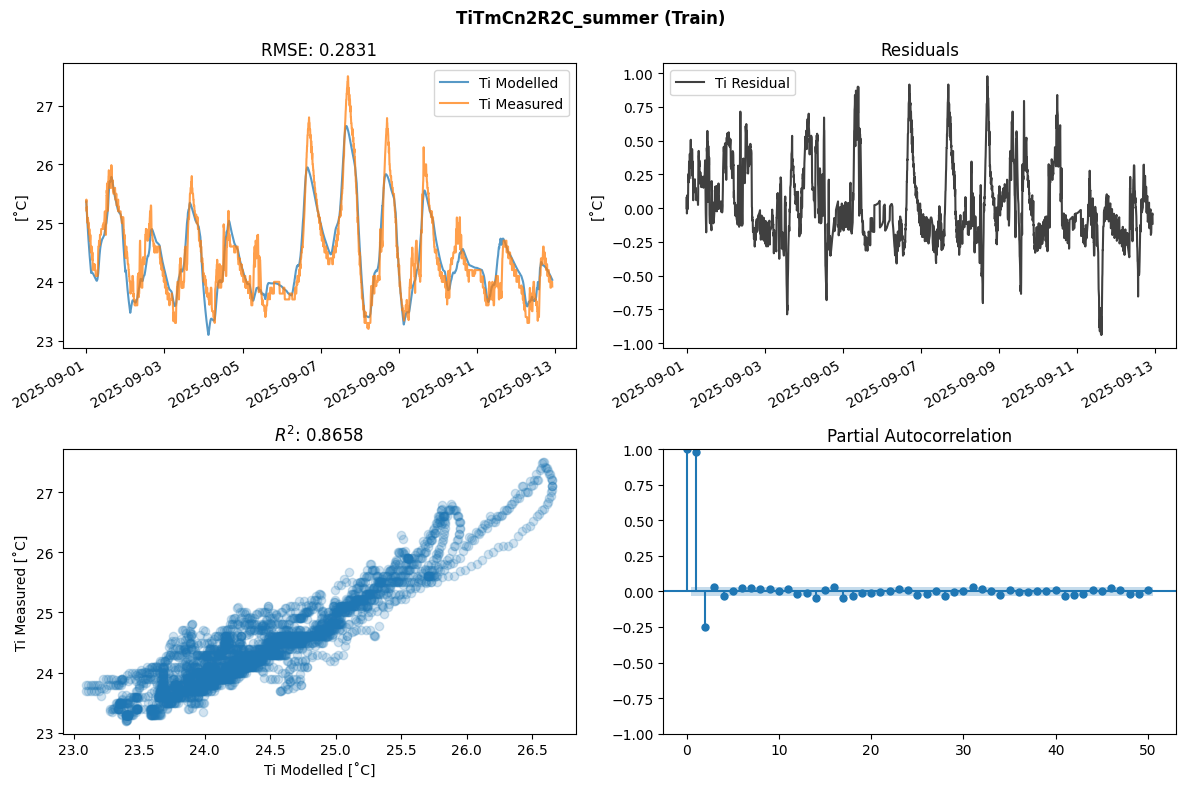

In [29]:
plot(y_train, train_results, 'TiTmCn2R2C_summer (Train)')

## Test results

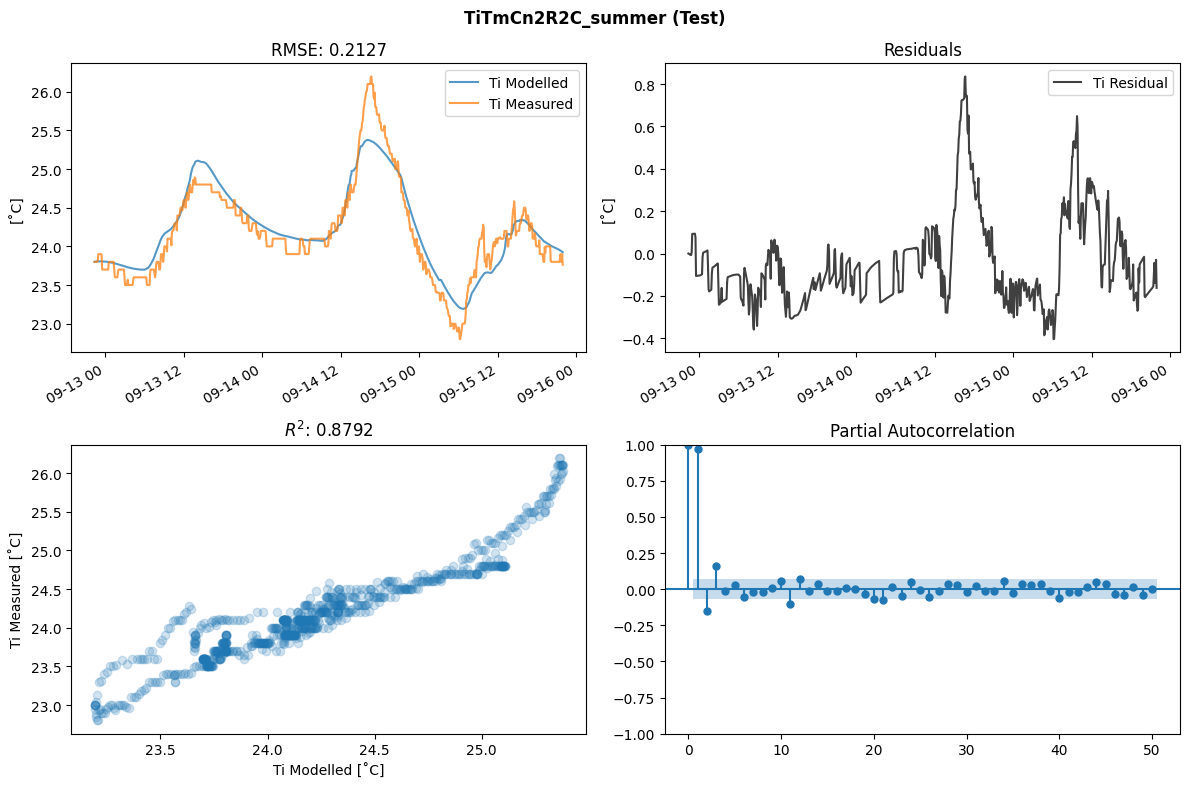

In [30]:
plot(y_test, test_results, 'TiTmCn2R2C_summer (Test)')

         EXTENDED MODEL VALIDATION REPORT (TEST)

── GOODNESS OF FIT (free-run simulation) ───────────────────
  RMSE:              0.2179 °C
  MAE:               0.1749 °C
  NRMSE (by range):  0.0641
  R²:                0.8732

── LIKELIHOOD-BASED CRITERIA ───────────────────────────────
  Log-Likelihood:     88.7344
  AIC (lower=better): -141.4687
  BIC (lower=better): -55.8439
  Parameters varied:  18

── RESIDUAL STATISTICS (free-run) ──────────────────────────
  Mean:     -0.061750 °C  (ideal ≈ 0)
  Std Dev:  0.209055 °C
  Skewness: 1.616800    (ideal ≈ 0)
  Kurtosis: 3.108232    (ideal ≈ 0)

── RESIDUAL STATISTICS (one-step-ahead) ────────────────────
  Mean:     -0.000203 °C  (ideal ≈ 0)
  Std Dev:  0.050246 °C
  Skewness: -0.502644    (ideal ≈ 0)
  Kurtosis: 4.073439    (ideal ≈ 0)

── NORMALITY TESTS — one-step (H0: Gaussian) ──────────────
  Shapiro-Wilk:  W=0.872933,  p=7.506e-26  ✗ Not Normal
  Jarque-Bera:   JB=630.0589,  p=1.529e-137  ✗ Not Normal

── LJUNG-BOX — one-ste

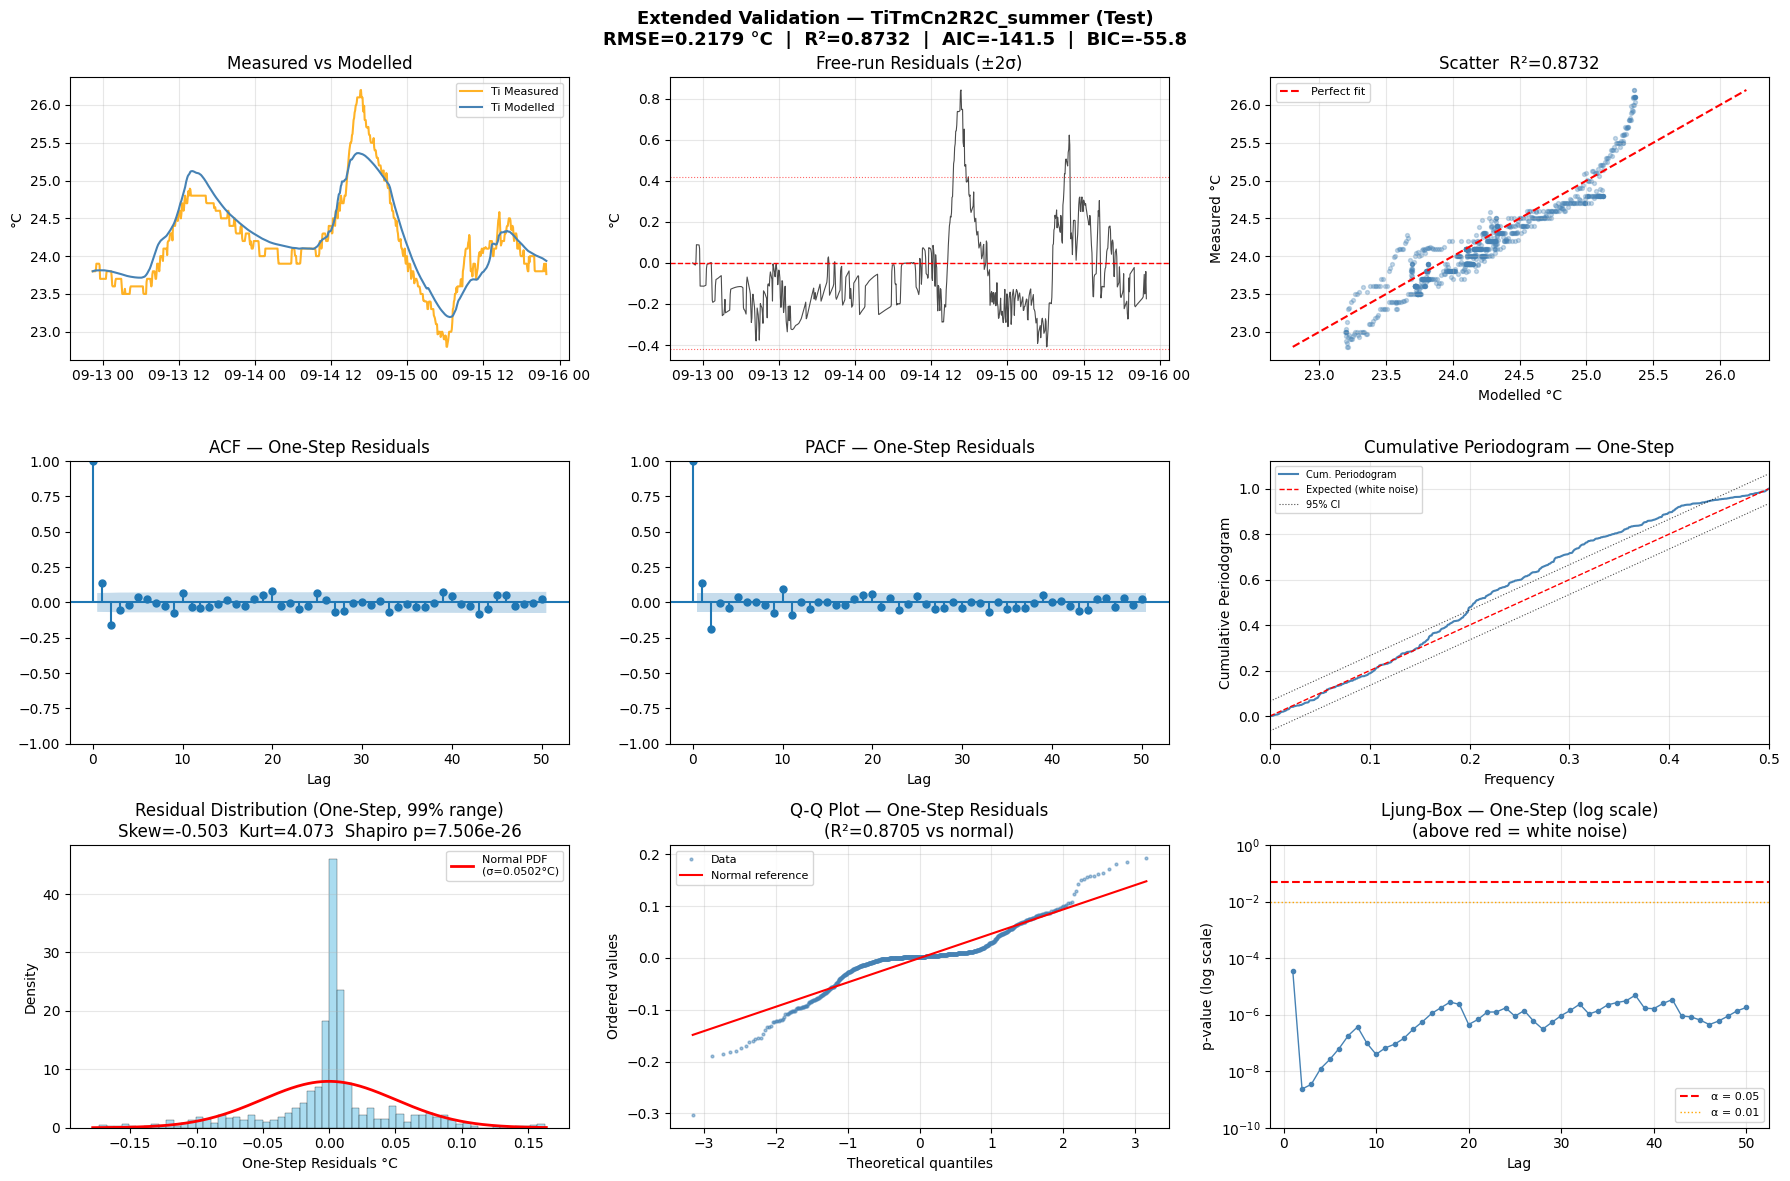

In [11]:
# ============================================================
# EXTENDED MODEL VALIDATION — FINAL VERSION (v3)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy import signal, stats
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
import warnings
warnings.filterwarnings('ignore')

# ----------------------------------------------------------
# 1. EXTRACT RESIDUALS — TWO TYPES
# ----------------------------------------------------------
Ti_measured  = y_test.values
Ti_modelled  = test_results.var['Ti']

# FREE-RUN → RMSE, R², MAE, scatter, time series
residuals    = Ti_measured - Ti_modelled
n            = len(residuals)

# ONE-STEP-AHEAD → ACF, PACF, Periodogram, Ljung-Box
residuals_1s = np.diff(residuals)
n1           = len(residuals_1s)

# ----------------------------------------------------------
# 2. COMPUTE ALL METRICS
# ----------------------------------------------------------

# Goodness of fit (free-run)
rmse_val  = np.sqrt(np.mean(residuals**2))
mae_val   = np.mean(np.abs(residuals))
ss_res    = np.sum(residuals**2)
ss_tot    = np.sum((Ti_measured - np.mean(Ti_measured))**2)
r2_val    = 1 - (ss_res / ss_tot)
nrmse_val = rmse_val / (Ti_measured.max() - Ti_measured.min())

# Likelihood-based metrics (free-run)
sigma2  = np.var(residuals, ddof=1)
log_lik = -0.5 * n * np.log(2 * np.pi * sigma2) - 0.5 * np.sum(residuals**2) / sigma2
if 'model' in locals() and hasattr(model, 'result') and hasattr(model.result, 'params'):
    k_params = sum(1 for p in model.result.params.values() if getattr(p, 'vary', False))
else:
    k_params = sum(1 for p in train_params_TiTmCn2R2C_summer_V4.values()
                   if isinstance(p, dict) and p.get('vary', False))
aic_val = -2 * log_lik + 2 * k_params
bic_val = -2 * log_lik + k_params * np.log(n)

# Free-run residual statistics
res_mean = np.mean(residuals)
res_std  = np.std(residuals, ddof=1)
res_skew = stats.skew(residuals)
res_kurt = stats.kurtosis(residuals)

# One-step residual statistics
res1_mean = np.mean(residuals_1s)
res1_std  = np.std(residuals_1s, ddof=1)
res1_skew = stats.skew(residuals_1s)
res1_kurt = stats.kurtosis(residuals_1s)

# Normality tests (one-step)
shapiro_stat, shapiro_p = stats.shapiro(residuals_1s[:min(5000, n1)])
jb_stat, jb_p           = stats.jarque_bera(residuals_1s)

# Ljung-Box (one-step)
lb_results = acorr_ljungbox(residuals_1s, lags=[1, 6, 12, 24, 48], return_df=True)

# ----------------------------------------------------------
# 3. PRINT VALIDATION REPORT  (scientific notation for p)
# ----------------------------------------------------------
def fmt_p(p):
    """Format p-value: show more precision, switch to sci notation if tiny."""
    if p < 0.0001:
        return f"{p:.3e}"
    return f"{p:.6f}"

print("=" * 65)
print("         EXTENDED MODEL VALIDATION REPORT (TEST)")
print("=" * 65)

print("\n── GOODNESS OF FIT (free-run simulation) ───────────────────")
print(f"  RMSE:              {rmse_val:.4f} °C")
print(f"  MAE:               {mae_val:.4f} °C")
print(f"  NRMSE (by range):  {nrmse_val:.4f}")
print(f"  R²:                {r2_val:.4f}")

print("\n── LIKELIHOOD-BASED CRITERIA ───────────────────────────────")
print(f"  Log-Likelihood:     {log_lik:.4f}")
print(f"  AIC (lower=better): {aic_val:.4f}")
print(f"  BIC (lower=better): {bic_val:.4f}")
print(f"  Parameters varied:  {k_params}")

print("\n── RESIDUAL STATISTICS (free-run) ──────────────────────────")
print(f"  Mean:     {res_mean:.6f} °C  (ideal ≈ 0)")
print(f"  Std Dev:  {res_std:.6f} °C")
print(f"  Skewness: {res_skew:.6f}    (ideal ≈ 0)")
print(f"  Kurtosis: {res_kurt:.6f}    (ideal ≈ 0)")

print("\n── RESIDUAL STATISTICS (one-step-ahead) ────────────────────")
print(f"  Mean:     {res1_mean:.6f} °C  (ideal ≈ 0)")
print(f"  Std Dev:  {res1_std:.6f} °C")
print(f"  Skewness: {res1_skew:.6f}    (ideal ≈ 0)")
print(f"  Kurtosis: {res1_kurt:.6f}    (ideal ≈ 0)")

print("\n── NORMALITY TESTS — one-step (H0: Gaussian) ──────────────")
print(f"  Shapiro-Wilk:  W={shapiro_stat:.6f},  p={fmt_p(shapiro_p)}  "
      f"{'✓ Normal' if shapiro_p > 0.05 else '✗ Not Normal'}")
print(f"  Jarque-Bera:   JB={jb_stat:.4f},  p={fmt_p(jb_p)}  "
      f"{'✓ Normal' if jb_p > 0.05 else '✗ Not Normal'}")

print("\n── LJUNG-BOX — one-step (H0: white noise) ─────────────────")
print(f"  {'Lag':<6} {'Q-stat':>10} {'p-value':>14}  Result")
print(f"  {'-'*46}")
for lag in [1, 6, 12, 24, 48]:
    row    = lb_results.loc[lag]
    result = '✓ White noise' if row['lb_pvalue'] > 0.05 else '✗ Autocorrelation'
    print(f"  {lag:<6} {row['lb_stat']:>10.4f} {fmt_p(row['lb_pvalue']):>14}  {result}")
print("=" * 65)

# ----------------------------------------------------------
# 4. DIAGNOSTIC PLOTS
# ----------------------------------------------------------
fig, axes = plt.subplots(3, 3, figsize=(18, 12))
fig.suptitle(
    f'Extended Validation — TiTmCn2R2C_summer (Test)\n'
    f'RMSE={rmse_val:.4f} °C  |  R²={r2_val:.4f}  |  AIC={aic_val:.1f}  |  BIC={bic_val:.1f}',
    fontsize=13, fontweight='bold'
)

time_idx    = y_test.index
time_idx_1s = y_test.index[1:]

# ── Plot 1: Time series ──────────────────────────────────
ax = axes[0, 0]
ax.plot(time_idx, Ti_measured, label='Ti Measured', color='orange',    lw=1.5, alpha=0.85)
ax.plot(time_idx, Ti_modelled, label='Ti Modelled', color='steelblue', lw=1.5)
ax.set_ylabel('°C')
ax.set_title('Measured vs Modelled')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# ── Plot 2: Free-run residuals ───────────────────────────
ax = axes[0, 1]
ax.plot(time_idx, residuals, color='black', lw=0.8, alpha=0.7)
ax.axhline(0,          color='red', ls='--', lw=1)
ax.axhline( 2*res_std, color='red', ls=':',  lw=0.8, alpha=0.6)
ax.axhline(-2*res_std, color='red', ls=':',  lw=0.8, alpha=0.6)
ax.set_ylabel('°C')
ax.set_title('Free-run Residuals (±2σ)')
ax.grid(alpha=0.3)

# ── Plot 3: Scatter ──────────────────────────────────────
ax = axes[0, 2]
ax.scatter(Ti_modelled, Ti_measured, alpha=0.3, s=8, color='steelblue')
lo = min(Ti_modelled.min(), Ti_measured.min())
hi = max(Ti_modelled.max(), Ti_measured.max())
ax.plot([lo, hi], [lo, hi], 'r--', lw=1.5, label='Perfect fit')
ax.set_xlabel('Modelled °C'); ax.set_ylabel('Measured °C')
ax.set_title(f'Scatter  R²={r2_val:.4f}')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# ── Plot 4: ACF (one-step) ───────────────────────────────
ax = axes[1, 0]
plot_acf(residuals_1s, lags=50, ax=ax, alpha=0.05)
ax.set_title('ACF — One-Step Residuals')
ax.set_xlabel('Lag')

# ── Plot 5: PACF (one-step) ──────────────────────────────
ax = axes[1, 1]
plot_pacf(residuals_1s, lags=50, ax=ax, alpha=0.05, method='ywm')
ax.set_title('PACF — One-Step Residuals')
ax.set_xlabel('Lag')

# ── Plot 6: Cumulative Periodogram (one-step) ────────────
ax = axes[1, 2]
freqs, Pxx = signal.periodogram(residuals_1s, fs=1.0)
cum_per    = np.cumsum(Pxx) / np.sum(Pxx)
m          = len(freqs)
K_alpha    = np.sqrt(-0.5 * np.log(0.05 / 2))
expected   = np.linspace(0, 1, m)
upper      = expected + K_alpha / np.sqrt(m)
lower      = expected - K_alpha / np.sqrt(m)
ax.plot(freqs, cum_per,  color='steelblue', lw=1.5, label='Cum. Periodogram')
ax.plot(freqs, expected, 'r--', lw=1,       label='Expected (white noise)')
ax.plot(freqs, upper,    'k:',  lw=0.8, alpha=0.7)
ax.plot(freqs, lower,    'k:',  lw=0.8, alpha=0.7, label='95% CI')
ax.set_xlim(0, 0.5)
ax.set_xlabel('Frequency'); ax.set_ylabel('Cumulative Periodogram')
ax.set_title('Cumulative Periodogram — One-Step')
ax.legend(fontsize=7); ax.grid(alpha=0.3)

# ── Plot 7: Histogram — FIX: clip x-axis to 99th percentile
ax = axes[2, 0]
p1, p99 = np.percentile(residuals_1s, 0.5), np.percentile(residuals_1s, 99.5)
res1_clipped = residuals_1s[(residuals_1s >= p1) & (residuals_1s <= p99)]
ax.hist(res1_clipped, bins=60, density=True, alpha=0.7,
        color='skyblue', edgecolor='black', lw=0.3)
x_fit = np.linspace(p1, p99, 300)
ax.plot(x_fit, stats.norm.pdf(x_fit, res1_mean, res1_std),
        'r-', lw=2, label=f'Normal PDF\n(σ={res1_std:.4f}°C)')
ax.set_xlabel('One-Step Residuals °C'); ax.set_ylabel('Density')
ax.set_title(f'Residual Distribution (One-Step, 99% range)\n'
             f'Skew={res1_skew:.3f}  Kurt={res1_kurt:.3f}  Shapiro p={fmt_p(shapiro_p)}')
ax.legend(fontsize=8); ax.grid(alpha=0.3, axis='y')

# ── Plot 8: Q-Q Plot — FIX: add reference line + annotation
ax = axes[2, 1]
(osm, osr), (slope, intercept, r) = stats.probplot(residuals_1s, dist='norm')
ax.plot(osm, osr,                  'o', color='steelblue', ms=2, alpha=0.5, label='Data')
ax.plot(osm, slope*np.array(osm) + intercept, 'r-', lw=1.5, label='Normal reference')
ax.set_xlabel('Theoretical quantiles'); ax.set_ylabel('Ordered values')
ax.set_title(f'Q-Q Plot — One-Step Residuals\n(R²={r**2:.4f} vs normal)')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# ── Plot 9: Ljung-Box — FIX: log scale so differences are visible
ax = axes[2, 2]
lb_all = acorr_ljungbox(residuals_1s, lags=50, return_df=True)
pvals  = lb_all['lb_pvalue'].values
lags   = lb_all.index.values
# Clip to avoid log(0)
pvals_plot = np.clip(pvals, 1e-10, 1.0)
ax.semilogy(lags, pvals_plot, 'o-', color='steelblue', ms=3, lw=1)
ax.axhline(0.05, color='red',    ls='--', lw=1.5, label='α = 0.05')
ax.axhline(0.01, color='orange', ls=':',  lw=1.0, label='α = 0.01')
ax.set_xlabel('Lag'); ax.set_ylabel('p-value (log scale)')
ax.set_title('Ljung-Box — One-Step (log scale)\n(above red = white noise)')
ax.legend(fontsize=8); ax.grid(alpha=0.3, which='both')
ax.set_ylim(1e-10, 1.0)

plt.tight_layout()
plt.show()

Baseline -log L at fitted params: 1620.3071

Profiling Ci (fitted=2118.5332)  range=[1000.0000, 3389.6531]
  Ci=1000.0000  →  -logL=2080.8144  Δ=460.5073
  Ci=1099.5689  →  -logL=1992.5225  Δ=372.2154
  Ci=1199.1378  →  -logL=1913.5817  Δ=293.2746
  Ci=1298.7066  →  -logL=1844.2564  Δ=223.9493
  Ci=1398.2755  →  -logL=1784.6593  Δ=164.3522
  Ci=1497.8444  →  -logL=1734.7498  Δ=114.4426
  Ci=1597.4133  →  -logL=1694.3378  Δ=74.0306
  Ci=1696.9821  →  -logL=1663.0940  Δ=42.7868
  Ci=1796.5510  →  -logL=1640.5661  Δ=20.2590
  Ci=1896.1199  →  -logL=1626.2009  Δ=5.8938
  Ci=1995.6888  →  -logL=1619.3687  Δ=-0.9384
  Ci=2095.2576  →  -logL=1619.3896  Δ=-0.9176
  Ci=2194.8265  →  -logL=1625.5579  Δ=5.2508
  Ci=2294.3954  →  -logL=1637.1650  Δ=16.8578
  Ci=2393.9643  →  -logL=1653.5178  Δ=33.2106
  Ci=2493.5332  →  -logL=1673.9538  Δ=53.6466
  Ci=2593.1020  →  -logL=1697.8518  Δ=77.5447
  Ci=2692.6709  →  -logL=1724.6392  Δ=104.3321
  Ci=2792.2398  →  -logL=1753.7956  Δ=133.4885
  Ci=2891.808

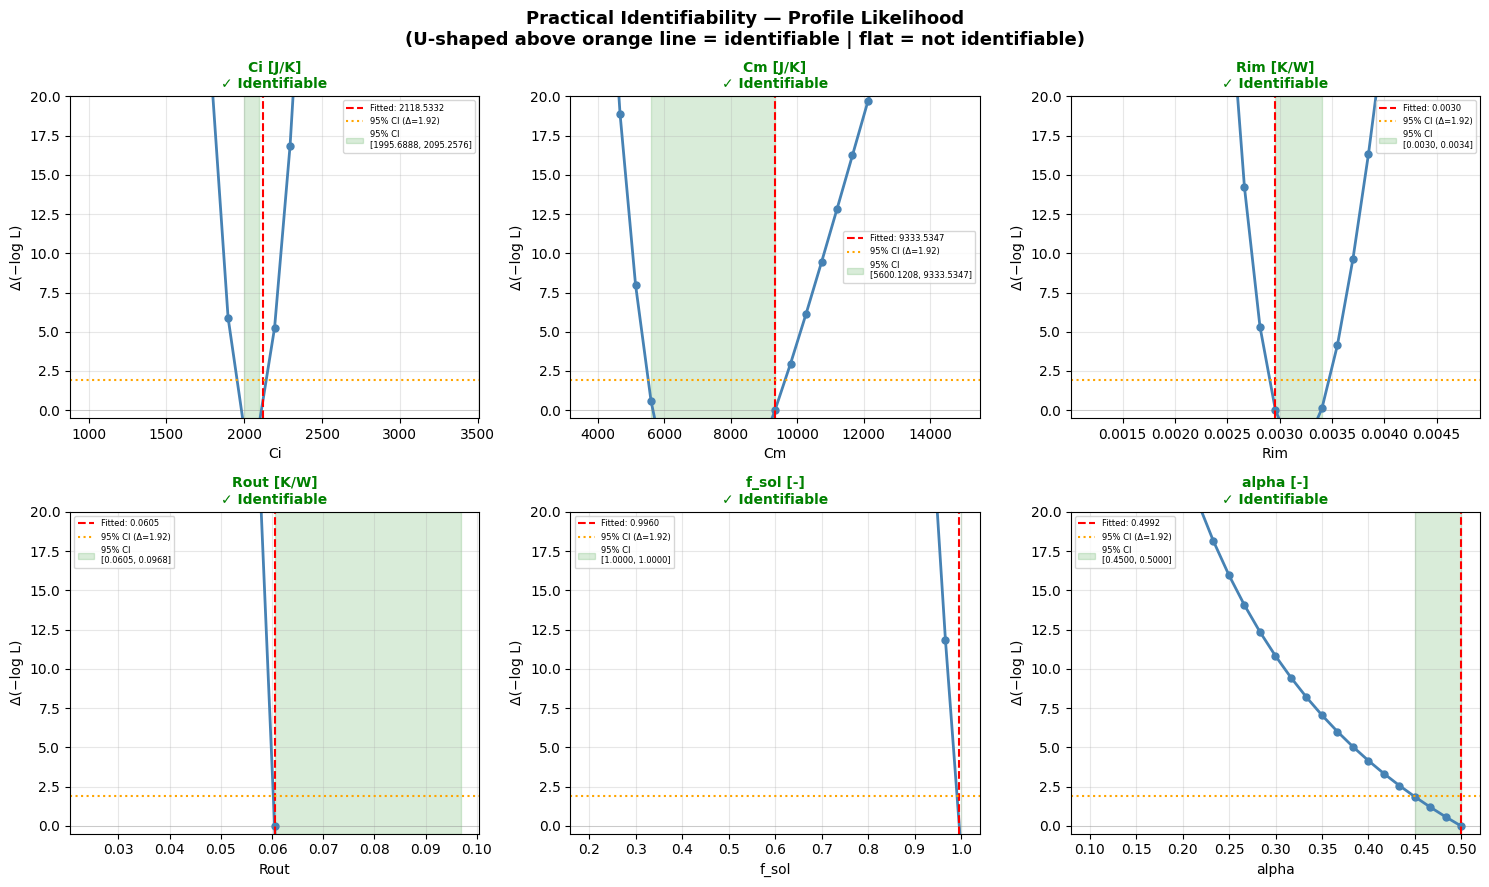

In [12]:
# ============================================================
# PRACTICAL IDENTIFIABILITY — PROFILE LIKELIHOOD (FIXED)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import lmfit

# ----------------------------------------------------------
# HELPER — rebuild params from scratch (avoids deepcopy bug)
# ----------------------------------------------------------
def compute_nll_at_param(param_name, param_val, fitted_model, fitted_params, X, y_vals):
    """
    Fix param_name=param_val, hold all others at fitted values.
    Uses the EXISTING model instance directly — no re-instantiation.
    """
    # Build fresh lmfit Parameters (avoids deepcopy issues)
    p = lmfit.Parameters()
    for name, par in fitted_params.items():
        p.add(name,
              value = par.value,
              vary  = False,           # all fixed for forward-run
              min   = par.min if np.isfinite(par.min) else -np.inf,
              max   = par.max if np.isfinite(par.max) else  np.inf)

    # Override the one parameter being profiled
    p[param_name].value = param_val

    try:
        result  = fitted_model.model(p, X)
        Ti_pred = np.asarray(result.var['Ti'])
        res     = y_vals - Ti_pred
        n       = len(res)
        sigma2  = np.var(res, ddof=1)
        if sigma2 <= 0 or not np.isfinite(sigma2):
            return np.nan
        return 0.5 * n * np.log(2 * np.pi * sigma2) + 0.5 * np.sum(res**2) / sigma2
    except Exception as e:
        print(f"    ⚠ Error at {param_name}={param_val:.4f}: {e}")
        return np.nan


# ----------------------------------------------------------
# SETUP
# ----------------------------------------------------------
# Use the existing trained model instance from darkgreyfit
fitted_model  = model          # the DarkGreyModel instance from df.iloc[0]
fitted_params = model.result.params

# Training data — adjust variable names to match your notebook
y_train_vals = y_train.values        # numpy array
X_train_dict = X_train               # DataFrame or dict — whatever your model.model() expects

# Compute best -log L at fitted params (baseline = 0)
best_nll = compute_nll_at_param(
    'Ci', fitted_params['Ci'].value,   # dummy call with fitted value = baseline
    fitted_model, fitted_params, X_train_dict, y_train_vals
)
print(f"Baseline -log L at fitted params: {best_nll:.4f}")

# ----------------------------------------------------------
# PARAMETERS TO PROFILE
# ----------------------------------------------------------
# (param_name, display_label, n_grid_points, fraction_of_range_to_explore)
profile_params = [
    ('Ci',    'Ci [J/K]',   25, 0.60),
    ('Cm',    'Cm [J/K]',   25, 0.60),
    ('Rim',   'Rim [K/W]',  25, 0.60),
    ('Rout',  'Rout [K/W]', 25, 0.60),
    ('f_sol', 'f_sol [-]',  25, 0.80),
    ('alpha', 'alpha [-]',  25, 0.80),
]

# ----------------------------------------------------------
# COMPUTE PROFILES
# ----------------------------------------------------------
profiles = {}

for param_name, label, n_pts, rel_range in profile_params:
    if param_name not in fitted_params:
        print(f"  Skipping {param_name} — not in fitted_params")
        continue

    fitted_val = fitted_params[param_name].value
    p_min      = fitted_params[param_name].min
    p_max      = fitted_params[param_name].max

    # Grid: ±rel_range around fitted value, clamped to bounds
    lo   = max(p_min if np.isfinite(p_min) else fitted_val*0.01,
               fitted_val * (1 - rel_range))
    hi   = min(p_max if np.isfinite(p_max) else fitted_val*100,
               fitted_val * (1 + rel_range))
    grid = np.linspace(lo, hi, n_pts)

    print(f"\nProfiling {param_name} (fitted={fitted_val:.4f})  range=[{lo:.4f}, {hi:.4f}]")

    nll_vals = []
    for val in grid:
        nll = compute_nll_at_param(
            param_name, val,
            fitted_model, fitted_params,
            X_train_dict, y_train_vals
        )
        nll_vals.append(nll)
        print(f"  {param_name}={val:.4f}  →  -logL={nll:.4f}  Δ={nll - best_nll:.4f}")

    profiles[param_name] = {
        'label':      label,
        'grid':       grid,
        'nll':        np.array(nll_vals),
        'fitted_val': fitted_val,
        'best_nll':   best_nll,
    }

# ----------------------------------------------------------
# PLOT
# ----------------------------------------------------------
n_plots  = len(profiles)
ncols    = 3
nrows    = int(np.ceil(n_plots / ncols))
chi2_thr = 1.92   # χ²(1, 0.95) / 2

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4.5 * nrows))
axes = axes.flatten()

for i, (param_name, data) in enumerate(profiles.items()):
    ax  = axes[i]
    raw = data['nll']
    delta = raw - data['best_nll']

    # Replace NaN with large value for plotting
    delta_plot = np.where(np.isfinite(delta), delta, np.nanmax(delta[np.isfinite(delta)] if np.any(np.isfinite(delta)) else [20]))

    ax.plot(data['grid'], delta_plot, 'o-', color='steelblue', lw=2, ms=5)
    ax.axvline(data['fitted_val'], color='red',    ls='--', lw=1.5,
               label=f"Fitted: {data['fitted_val']:.4f}")
    ax.axhline(chi2_thr, color='orange', ls=':', lw=1.5,
               label=f'95% CI (Δ={chi2_thr})')
    ax.axhline(0, color='gray', ls='-', lw=0.5, alpha=0.4)

    # Shade 95% CI region
    ci_mask = delta_plot <= chi2_thr
    if ci_mask.any():
        ci_lo = data['grid'][ci_mask].min()
        ci_hi = data['grid'][ci_mask].max()
        ax.axvspan(ci_lo, ci_hi, alpha=0.15, color='green',
                   label=f'95% CI\n[{ci_lo:.4f}, {ci_hi:.4f}]')

    # Verdict
    max_delta = np.nanmax(delta_plot)
    if max_delta > chi2_thr and np.nanmin(delta_plot) < 0.5:
        verdict, col = '✓ Identifiable', 'green'
    elif max_delta < chi2_thr:
        verdict, col = '✗ Not identifiable (flat)', 'red'
    else:
        verdict, col = '⚠ Weakly identifiable', 'orange'

    ax.set_title(f'{data["label"]}\n{verdict}', color=col, fontweight='bold', fontsize=10)
    ax.set_xlabel(param_name); ax.set_ylabel('Δ(−log L)')
    ax.legend(fontsize=6); ax.grid(alpha=0.3)
    ax.set_ylim(-0.5, min(max_delta * 1.1 + 1, 20))

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Practical Identifiability — Profile Likelihood\n'
             '(U-shaped above orange line = identifiable | flat = not identifiable)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## Plot the different heat gains

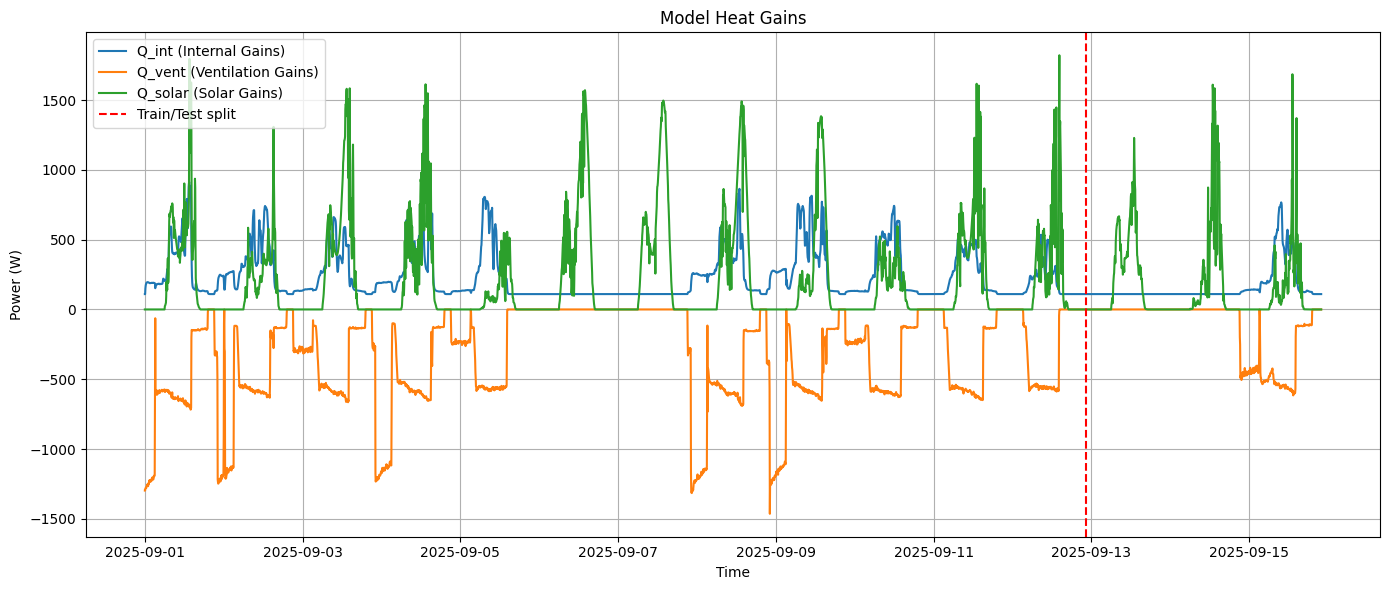

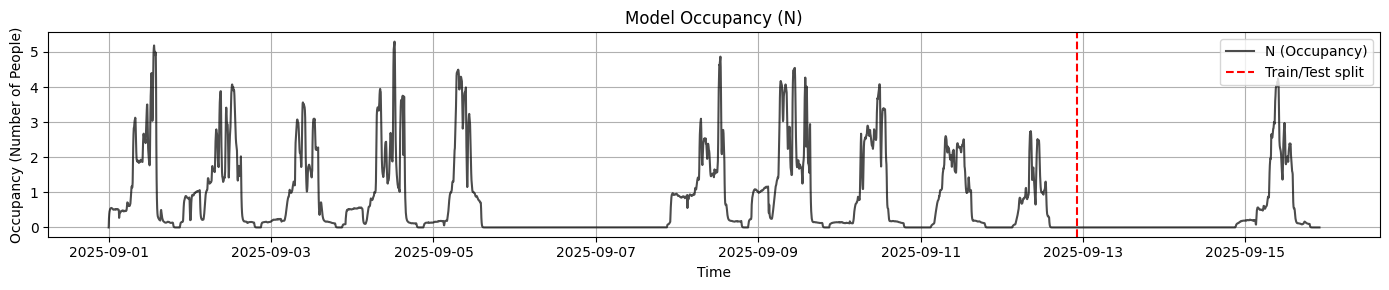

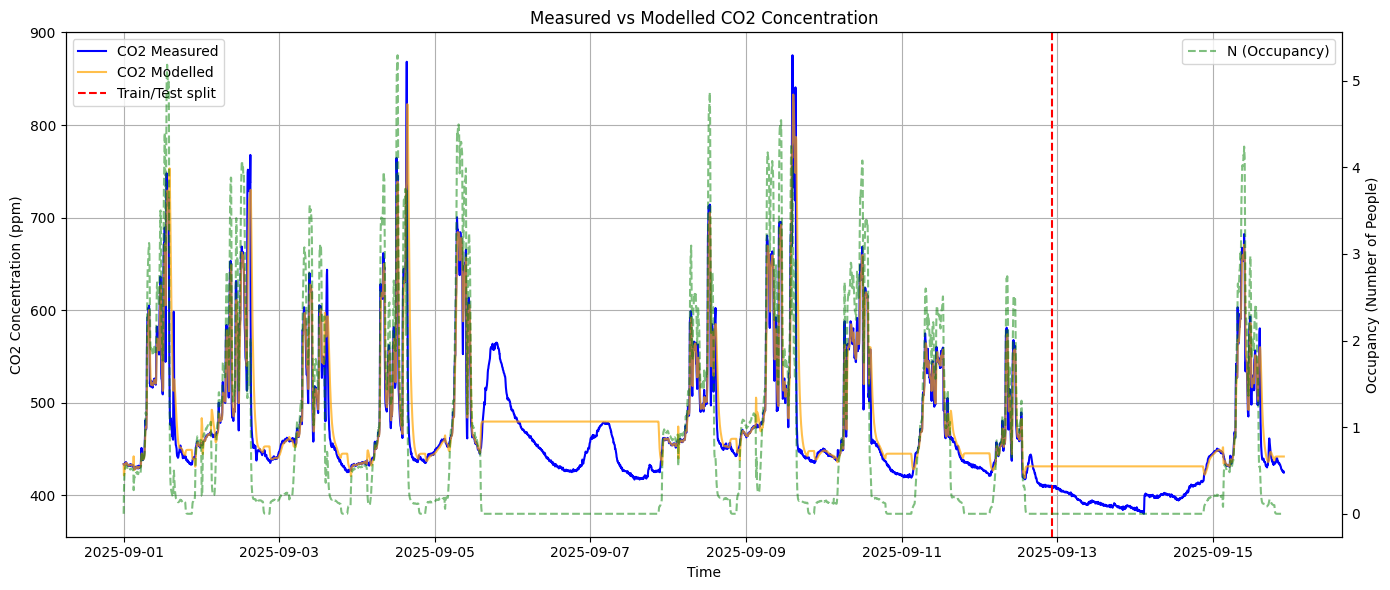

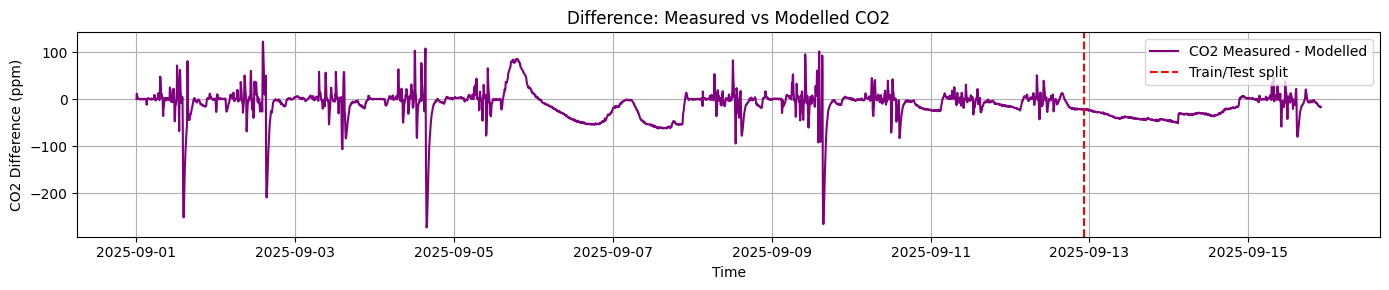

In [13]:
# Helper function to safely extract variables from results
def get_var(result, key, default=0):
    return result.var[key] if key in result.var else np.zeros(len(result.var[list(result.var.keys())[0]]))

# Extract Q_int, Q_vent, Q_solar, and N from train and test results
Q_int_train = get_var(train_results, 'Q_int')
Q_vent_train = get_var(train_results, 'Q_vent')
Q_solar_train = get_var(train_results, 'Q_solar')
N_train = get_var(train_results, 'N')

Q_int_test = get_var(test_results, 'Q_int')
Q_vent_test = get_var(test_results, 'Q_vent')
Q_solar_test = get_var(test_results, 'Q_solar')
N_test = get_var(test_results, 'N')

# Concatenate train and test for full time series
Q_int_full = np.concatenate([Q_int_train, Q_int_test])
Q_vent_full = np.concatenate([Q_vent_train, Q_vent_test])
Q_solar_full = np.concatenate([Q_solar_train, Q_solar_test])
N_full = np.concatenate([N_train, N_test])

# Get full index from y_train and y_test
full_index = pd.Index(list(y_train.index) + list(y_test.index))

# Plot heat gains
fig1, ax1 = plt.subplots(figsize=(14, 6))
ax1.plot(full_index, Q_int_full, label='Q_int (Internal Gains)')
ax1.plot(full_index, Q_vent_full, label='Q_vent (Ventilation Gains)')
ax1.plot(full_index, Q_solar_full, label='Q_solar (Solar Gains)')
ax1.axvline(x=y_train.index[-1], color='r', linestyle='--', label='Train/Test split')
ax1.set_xlabel('Time')
ax1.set_ylabel('Power (W)')
ax1.set_title('Model Heat Gains')
ax1.legend(loc='upper left')
ax1.grid(True)
plt.tight_layout()
plt.show()

# Plot N (occupancy) separately
fig2, ax2 = plt.subplots(figsize=(14, 3))
ax2.plot(full_index, N_full, color='black', label='N (Occupancy)', linewidth=1.5, alpha=0.7)
ax2.axvline(x=y_train.index[-1], color='r', linestyle='--', label='Train/Test split')
ax2.set_xlabel('Time')
ax2.set_ylabel('Occupancy (Number of People)')
ax2.set_title('Model Occupancy (N)')
ax2.legend(loc='upper right')
ax2.grid(True)
plt.tight_layout()
plt.show()


# Plot the difference between measured CO2 (c) and modelled CO2, along with N
# Extract measured and modelled CO2 concentrations
c_measured = pd.concat([input_df.loc[y_train.index, 'c'], input_df.loc[y_test.index, 'c']])
c_modelled = np.concatenate([get_var(train_results, 'c'), get_var(test_results, 'c')])

# Plot measured vs modelled CO2 and N
fig3, ax3 = plt.subplots(figsize=(14, 6))
ax3.plot(full_index, c_measured, label='CO2 Measured', color='blue')
ax3.plot(full_index, c_modelled, label='CO2 Modelled', color='orange', alpha=0.7)
ax3.axvline(x=y_train.index[-1], color='r', linestyle='--', label='Train/Test split')
ax3.set_xlabel('Time')
ax3.set_ylabel('CO2 Concentration (ppm)')
ax3.set_title('Measured vs Modelled CO2 Concentration')
ax3.legend(loc='upper left')
ax3.grid(True)

# Add a secondary axis for N
ax4 = ax3.twinx()
ax4.plot(full_index, N_full, label='N (Occupancy)', color='green', linestyle='--', alpha=0.5)
ax4.set_ylabel('Occupancy (Number of People)')
ax4.legend(loc='upper right')

plt.tight_layout()
plt.show()

# Plot the difference between measured and modelled CO2
fig4, ax5 = plt.subplots(figsize=(14, 3))
co2_diff = c_measured.values - c_modelled
ax5.plot(full_index, co2_diff, label='CO2 Measured - Modelled', color='purple')
ax5.axvline(x=y_train.index[-1], color='r', linestyle='--', label='Train/Test split')
ax5.set_xlabel('Time')
ax5.set_ylabel('CO2 Difference (ppm)')
ax5.set_title('Difference: Measured vs Modelled CO2')
ax5.legend(loc='upper right')
ax5.grid(True)
plt.tight_layout()
plt.show()

New results

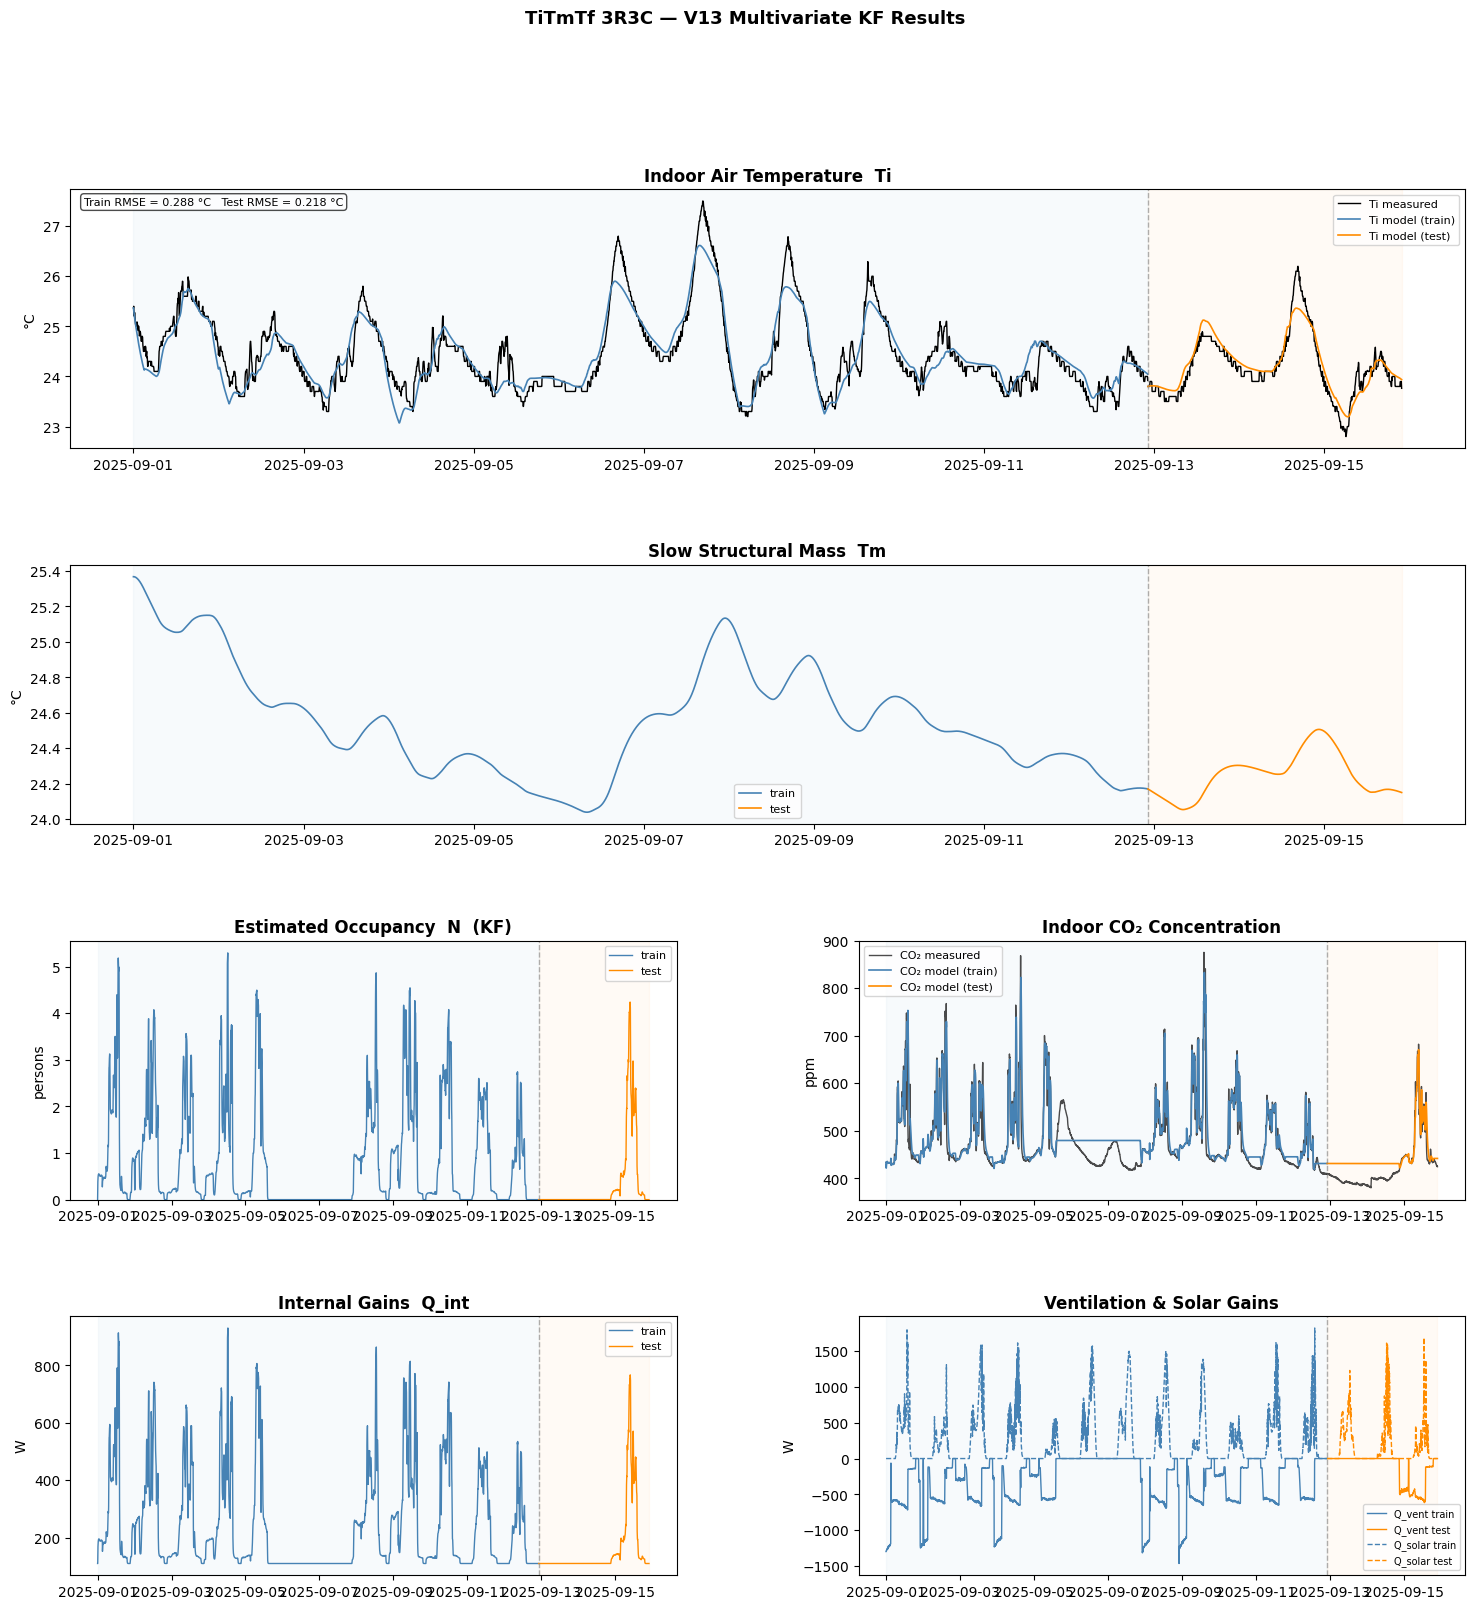

In [14]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

# ── Reconstruct time index ────────────────────────────────────────────────────
train_index = X_train.index
test_index  = X_test.index

# ── Unpack results ────────────────────────────────────────────────────────────
Ti_train   = get_var(train_results, 'Ti')
Tm_train   = get_var(train_results, 'Tm')
N_train    = get_var(train_results, 'N')
c_train    = get_var(train_results, 'c')
Qint_train = get_var(train_results, 'Q_int')
Qven_train = get_var(train_results, 'Q_vent')
Qsol_train = get_var(train_results, 'Q_solar')

Ti_test    = get_var(test_results, 'Ti')
Tm_test    = get_var(test_results, 'Tm')
N_test     = get_var(test_results, 'N')
c_test     = get_var(test_results, 'c')
Qint_test  = get_var(test_results, 'Q_int')
Qven_test  = get_var(test_results, 'Q_vent')
Qsol_test  = get_var(test_results, 'Q_solar')

c_meas_train = np.asarray(X_train['c'], dtype=float)
c_meas_test  = np.asarray(X_test['c'],  dtype=float)

# ── Figure layout — 4 rows, no innovation panel ───────────────────────────────
fig = plt.figure(figsize=(18, 18))
gs  = gridspec.GridSpec(4, 2, figure=fig, hspace=0.45, wspace=0.3)

ax_ti   = fig.add_subplot(gs[0, :])
ax_tm   = fig.add_subplot(gs[1, :])
ax_n    = fig.add_subplot(gs[2, 0])
ax_co2  = fig.add_subplot(gs[2, 1])
ax_qint = fig.add_subplot(gs[3, 0])
ax_qven = fig.add_subplot(gs[3, 1])

# ── Helper ────────────────────────────────────────────────────────────────────
def shade_split(ax):
    ax.axvline(test_index[0], color='grey', lw=1, ls='--', alpha=0.6)
    ax.axvspan(train_index[0], test_index[0],  alpha=0.04, color='steelblue')
    ax.axvspan(test_index[0],  test_index[-1], alpha=0.04, color='darkorange')

# ── 1. Ti ─────────────────────────────────────────────────────────────────────
ax_ti.plot(train_index, y_train,  color='black',      lw=1.0, label='Ti measured')
ax_ti.plot(train_index, Ti_train, color='steelblue',  lw=1.2, label='Ti model (train)')
ax_ti.plot(test_index,  y_test,   color='black',      lw=1.0)
ax_ti.plot(test_index,  Ti_test,  color='darkorange', lw=1.2, label='Ti model (test)')
shade_split(ax_ti)
ax_ti.set_title('Indoor Air Temperature  Ti', fontweight='bold')
ax_ti.set_ylabel('°C')
ax_ti.legend(fontsize=8)
ax_ti.text(0.01, 0.97,
    f'Train RMSE = {rmse(Ti_train, y_train.values):.3f} °C   '
    f'Test RMSE = {rmse(Ti_test, y_test.values):.3f} °C',
    transform=ax_ti.transAxes, va='top', fontsize=8,
    bbox=dict(boxstyle='round', fc='white', alpha=0.7))

# ── 2. Tm — full width ────────────────────────────────────────────────────────
ax_tm.plot(train_index, Tm_train, color='steelblue',  lw=1.2, label='train')
ax_tm.plot(test_index,  Tm_test,  color='darkorange', lw=1.2, label='test')
shade_split(ax_tm)
ax_tm.set_title('Slow Structural Mass  Tm', fontweight='bold')
ax_tm.set_ylabel('°C')
ax_tm.legend(fontsize=8)

# ── 3. Occupancy N ────────────────────────────────────────────────────────────
ax_n.plot(train_index, N_train, color='steelblue',  lw=1.0, label='train')
ax_n.plot(test_index,  N_test,  color='darkorange', lw=1.0, label='test')
ax_n.set_ylim(bottom=0)
shade_split(ax_n)
ax_n.set_title('Estimated Occupancy  N  (KF)', fontweight='bold')
ax_n.set_ylabel('persons')
ax_n.legend(fontsize=8)

# ── 4. CO2 ────────────────────────────────────────────────────────────────────
ax_co2.plot(train_index, c_meas_train, color='black',      lw=1.0, alpha=0.7, label='CO₂ measured')
ax_co2.plot(train_index, c_train,      color='steelblue',  lw=1.2, label='CO₂ model (train)')
ax_co2.plot(test_index,  c_meas_test,  color='black',      lw=1.0, alpha=0.7)
ax_co2.plot(test_index,  c_test,       color='darkorange', lw=1.2, label='CO₂ model (test)')
shade_split(ax_co2)
ax_co2.set_title('Indoor CO₂ Concentration', fontweight='bold')
ax_co2.set_ylabel('ppm')
ax_co2.legend(fontsize=8)

# ── 5. Internal heat gains ────────────────────────────────────────────────────
ax_qint.plot(train_index, Qint_train, color='steelblue',  lw=1.0, label='train')
ax_qint.plot(test_index,  Qint_test,  color='darkorange', lw=1.0, label='test')
shade_split(ax_qint)
ax_qint.set_title('Internal Gains  Q_int', fontweight='bold')
ax_qint.set_ylabel('W')
ax_qint.legend(fontsize=8)

# ── 6. Ventilation + solar ────────────────────────────────────────────────────
ax_qven.plot(train_index, Qven_train, color='steelblue',  lw=1.0, label='Q_vent train')
ax_qven.plot(test_index,  Qven_test,  color='darkorange', lw=1.0, label='Q_vent test')
ax_qven.plot(train_index, Qsol_train, color='steelblue',  lw=1.0, ls='--', label='Q_solar train')
ax_qven.plot(test_index,  Qsol_test,  color='darkorange', lw=1.0, ls='--', label='Q_solar test')
shade_split(ax_qven)
ax_qven.set_title('Ventilation & Solar Gains', fontweight='bold')
ax_qven.set_ylabel('W')
ax_qven.legend(fontsize=7)

# ── Save ──────────────────────────────────────────────────────────────────────
fig.suptitle('TiTmTf 3R3C — V13 Multivariate KF Results',
             fontsize=13, fontweight='bold')
plt.savefig('V13_results.png', dpi=150, bbox_inches='tight')
plt.show()


# NIGHT VENTILATION

## Baseline + single scenario comparison

Metric                        Baseline   Night vent 22-07
---------------------------------------------------------
dh_above                          2.07 °Ch           1.11 °Ch
dh_below                          0.00 °Ch           0.00 °Ch
pct_ok                           96.32 %          96.81 %
Ti_peak                          26.61 °C          26.38 °C
Ti_mean                          24.64 °C          24.47 °C


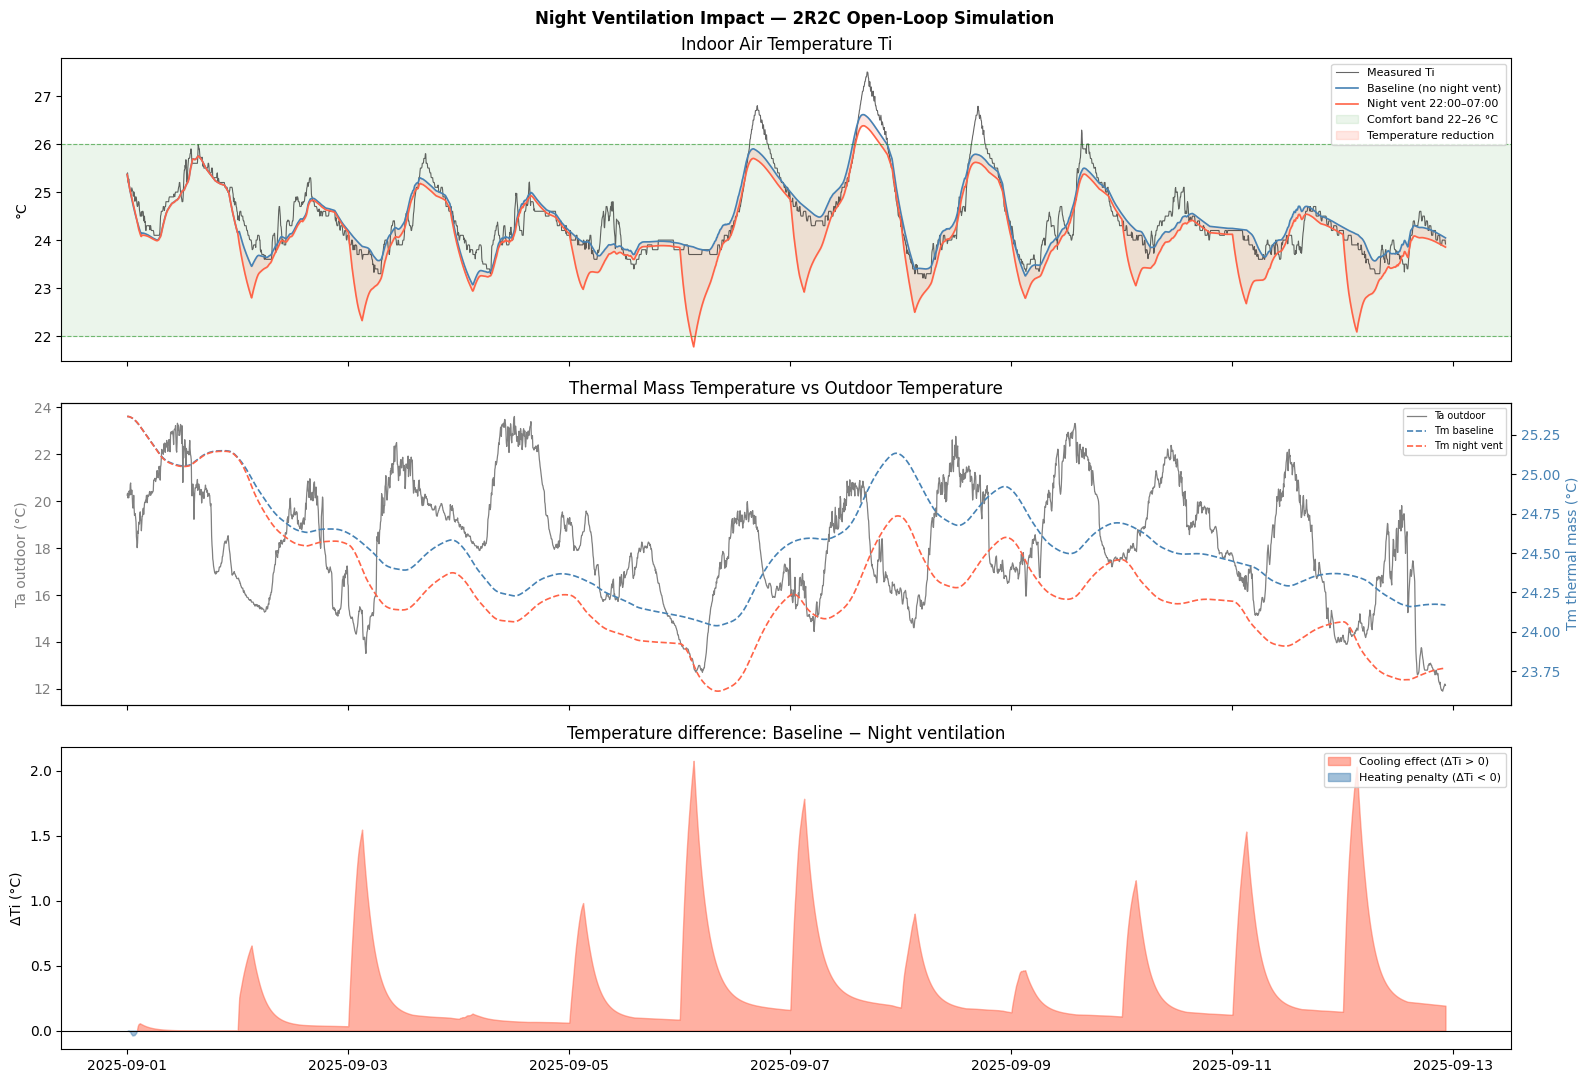

In [15]:
# Get fitted parameters from the trained model
fitted_params = model.result.params

# ── Shared initial conditions and occupancy ──────────────────────────────────
Ti_init = float(y_train.iloc[0])
Tm_init = float(train_results.var['Tm'][0])
c_init  = float(train_results.var['c'][0])
N_hist  = train_results.var['N']      # Estimated occupancy from model

# ── BASELINE: no extra night ventilation ─────────────────────────────────────
baseline = simulate_night_vent_scenario(
    fitted_params, X_train, N_hist,
    night_start_hour=0, night_stop_hour=0,   # no-op (mask always False)
    qv_night=0,
    rec_duration=rec_duration,
    Ti_init=Ti_init, Tm_init=Tm_init, c_init=c_init
)

# ── SCENARIO: night vent 22:00–07:00 at 3× normal flow ───────────────────────
qv_normal_max = float(np.percentile(np.asarray(X_train['qv'], dtype=float), 90))
qv_night_rate = 3.0 * qv_normal_max     # adjust to your system capacity

scenario = simulate_night_vent_scenario(
    fitted_params, X_train, N_hist,
    night_start_hour=0, night_stop_hour=3,
    qv_night=qv_night_rate,
    rec_duration=rec_duration,
    Ti_init=Ti_init, Tm_init=Tm_init, c_init=c_init
)

m_base = comfort_metrics(baseline['Ti'], X_train.index)
m_scen = comfort_metrics(scenario['Ti'], X_train.index)

print(f"{'Metric':<25} {'Baseline':>12} {'Night vent 22-07':>18}")
print("-" * 57)
for k in ['dh_above', 'dh_below', 'pct_ok', 'Ti_peak', 'Ti_mean']:
    unit = ' °Ch' if 'dh' in k else (' %' if 'pct' in k else ' °C')
    print(f"{k:<25} {m_base[k]:>12.2f}{unit}   {m_scen[k]:>12.2f}{unit}")

# ── Plot baseline vs scenario ─────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(16, 11), sharex=True)
fig.suptitle('Night Ventilation Impact — 2R2C Open-Loop Simulation', fontweight='bold')

# ── 1. Ti ─────────────────────────────────────────────────────────────────────
ax = axes[0]
ax.plot(X_train.index, y_train,        color='black',     lw=0.8, alpha=0.6, label='Measured Ti')
ax.plot(X_train.index, baseline['Ti'], color='steelblue', lw=1.2, label='Baseline (no night vent)')
ax.plot(X_train.index, scenario['Ti'], color='tomato',    lw=1.2, label='Night vent 22:00–07:00')
ax.axhspan(22, 26, alpha=0.08, color='green', label='Comfort band 22–26 °C')
ax.axhline(26, color='green', lw=0.8, ls='--', alpha=0.5)
ax.axhline(22, color='green', lw=0.8, ls='--', alpha=0.5)
ax.fill_between(X_train.index,
    baseline['Ti'], scenario['Ti'],
    where=(baseline['Ti'] > scenario['Ti']),
    alpha=0.15, color='tomato', label='Temperature reduction')
ax.set_ylabel('°C')
ax.legend(fontsize=8)
ax.set_title('Indoor Air Temperature Ti')

# ── 2. Tm vs Ta — dual y-axis ─────────────────────────────────────────────────
ax_ta = axes[1]                          # left axis  → Ta outdoor
ax_tm = ax_ta.twinx()                    # right axis → Tm thermal mass

Ta_arr = np.asarray(X_train['Ta'], dtype=float)

l1, = ax_ta.plot(X_train.index, Ta_arr,           color='grey',      lw=0.9, label='Ta outdoor')
l2, = ax_tm.plot(X_train.index, baseline['Tm'],   color='steelblue', lw=1.2, ls='--', label='Tm baseline')
l3, = ax_tm.plot(X_train.index, scenario['Tm'],   color='tomato',    lw=1.2, ls='--', label='Tm night vent')

ax_ta.set_ylabel('Ta outdoor (°C)', color='grey')
ax_ta.tick_params(axis='y', labelcolor='grey')

ax_tm.set_ylabel('Tm thermal mass (°C)', color='steelblue')
ax_tm.tick_params(axis='y', labelcolor='steelblue')

# combined legend
lines  = [l1, l2, l3]
labels = [l.get_label() for l in lines]
ax_ta.legend(lines, labels, fontsize=7, loc='upper right')
ax_ta.set_title('Thermal Mass Temperature vs Outdoor Temperature')

# ── 3. Delta Ti ───────────────────────────────────────────────────────────────
ax = axes[2]
delta_Ti = baseline['Ti'].values - scenario['Ti'].values
ax.fill_between(X_train.index, delta_Ti, 0,
    where=(delta_Ti > 0), color='tomato',    alpha=0.5, label='Cooling effect (ΔTi > 0)')
ax.fill_between(X_train.index, delta_Ti, 0,
    where=(delta_Ti < 0), color='steelblue', alpha=0.5, label='Heating penalty (ΔTi < 0)')
ax.axhline(0, color='black', lw=0.8)
ax.set_ylabel('ΔTi (°C)')
ax.legend(fontsize=8)
ax.set_title('Temperature difference: Baseline − Night ventilation')

plt.tight_layout()
plt.savefig('night_vent_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


## Analysis of current night ventilation

  EXISTING NIGHT VENTILATION ANALYSIS
  Night window           : 22:00 – 07:00
  qv threshold used      : 0.0 m³/h
  Night steps total      : 1276
  Night vent active      : 931 steps  (73.0%)
  Free cooling active    : 931 steps  (73.0%)
  Missed opportunities   : 345 steps  (27.0%)
  Mean qv (night, active): 181.2 m³/h
  Max  qv (night)        : 361.9 m³/h
  Mean qv (daytime)      : 114.1 m³/h
  Mean ΔT when active    : 6.69 °C  (Ti − Ta)
  Mean ΔT missed opport. : 9.02 °C  (Ti − Ta)


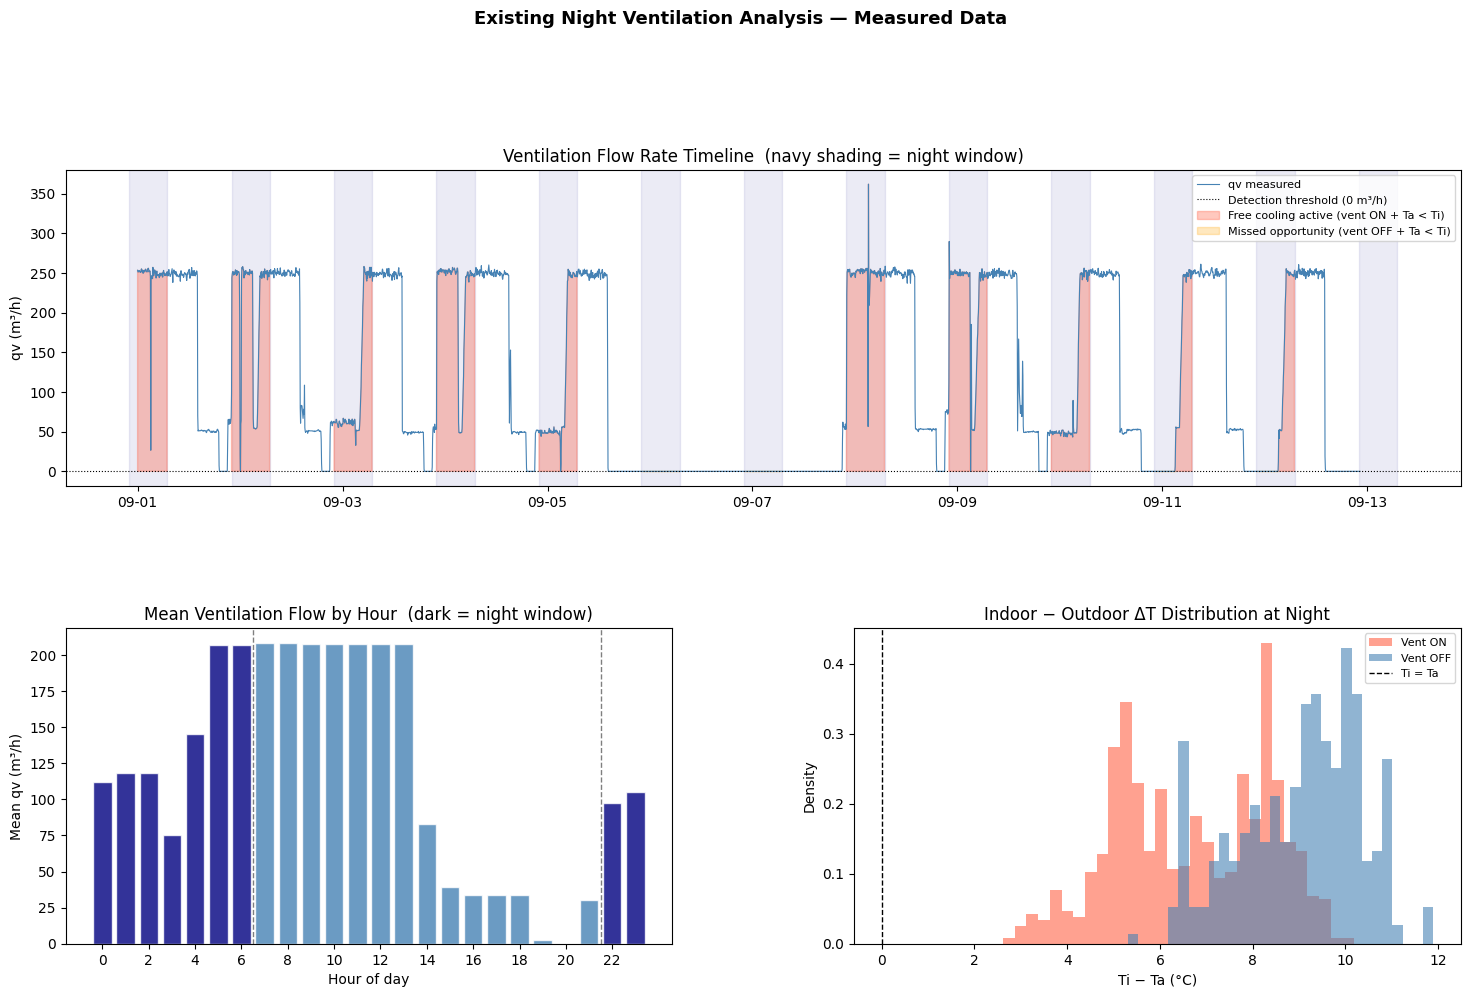

In [16]:
# ════════════════════════════════════════════════════════════════════════════
#  NIGHT VENTILATION ANALYSIS — existing behaviour in measured data
# ════════════════════════════════════════════════════════════════════════════

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd

# ── Config ───────────────────────────────────────────────────────────────────
NIGHT_START   = 22      # hour (inclusive)
NIGHT_STOP    = 7       # hour (exclusive, crosses midnight)
QV_THRESHOLD  = float(np.percentile(np.asarray(X_train['qv'], dtype=float), 25))
                        # anything above 25th percentile at night = "ventilation active"

# ── Raw arrays ───────────────────────────────────────────────────────────────
index   = X_train.index
qv_arr  = np.asarray(X_train['qv'],  dtype=float)
Ta_arr  = np.asarray(X_train['Ta'],  dtype=float)
Ti_meas = np.asarray(y_train,        dtype=float)
hours   = np.array([t.hour + t.minute / 60.0 for t in index])
dt_h    = (index[1] - index[0]).seconds / 3600.0

# ── Night mask (crosses midnight) ────────────────────────────────────────────
night_mask = (hours >= NIGHT_START) | (hours < NIGHT_STOP)

# ── Detect night ventilation events ──────────────────────────────────────────
night_vent_active = night_mask & (qv_arr > QV_THRESHOLD)
free_cooling_ok   = night_mask & (qv_arr > QV_THRESHOLD) & (Ta_arr < Ti_meas)
free_cooling_miss = night_mask & (qv_arr <= QV_THRESHOLD) & (Ta_arr < Ti_meas)
                    # night, no vent, but outdoor is cooler → missed opportunity

# ── Summary statistics ────────────────────────────────────────────────────────
n_night_steps        = night_mask.sum()
n_vent_steps         = night_vent_active.sum()
n_free_cooling_steps = free_cooling_ok.sum()
n_missed_steps       = free_cooling_miss.sum()

pct_night_vented     = 100 * n_vent_steps / n_night_steps if n_night_steps > 0 else 0
pct_free_cooling     = 100 * n_free_cooling_steps / n_night_steps if n_night_steps > 0 else 0
pct_missed           = 100 * n_missed_steps / n_night_steps if n_night_steps > 0 else 0

qv_night_mean = qv_arr[night_vent_active].mean() if n_vent_steps > 0 else 0
qv_night_max  = qv_arr[night_vent_active].max()  if n_vent_steps > 0 else 0
qv_day_mean   = qv_arr[~night_mask].mean()

delta_T_free  = (Ti_meas - Ta_arr)[free_cooling_ok]   # Ti - Ta when free cooling active
delta_T_miss  = (Ti_meas - Ta_arr)[free_cooling_miss]  # Ti - Ta when opportunity missed

print("=" * 60)
print("  EXISTING NIGHT VENTILATION ANALYSIS")
print("=" * 60)
print(f"  Night window           : {NIGHT_START}:00 – {NIGHT_STOP:02d}:00")
print(f"  qv threshold used      : {QV_THRESHOLD:.1f} m³/h")
print(f"  Night steps total      : {n_night_steps}")
print(f"  Night vent active      : {n_vent_steps} steps  ({pct_night_vented:.1f}%)")
print(f"  Free cooling active    : {n_free_cooling_steps} steps  ({pct_free_cooling:.1f}%)")
print(f"  Missed opportunities   : {n_missed_steps} steps  ({pct_missed:.1f}%)")
print(f"  Mean qv (night, active): {qv_night_mean:.1f} m³/h")
print(f"  Max  qv (night)        : {qv_night_max:.1f} m³/h")
print(f"  Mean qv (daytime)      : {qv_day_mean:.1f} m³/h")
if len(delta_T_free) > 0:
    print(f"  Mean ΔT when active    : {delta_T_free.mean():.2f} °C  (Ti − Ta)")
if len(delta_T_miss) > 0:
    print(f"  Mean ΔT missed opport. : {delta_T_miss.mean():.2f} °C  (Ti − Ta)")
print("=" * 60)

# ── Hourly profile: mean qv by hour ──────────────────────────────────────────
hour_int   = np.array([t.hour for t in index])
qv_by_hour = np.array([qv_arr[hour_int == h].mean() for h in range(24)])

# ── Figure ────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 16))
gs  = fig.add_gridspec(3, 2, hspace=0.45, wspace=0.3)

ax1 = fig.add_subplot(gs[0, :])   # full width — qv timeline
ax2 = fig.add_subplot(gs[1, 0])   # hourly qv profile
ax3 = fig.add_subplot(gs[1, 1])   # ΔT histogram (Ti - Ta) during night

fig.suptitle('Existing Night Ventilation Analysis — Measured Data', fontsize=13, fontweight='bold')

# ── 1. qv timeline with night shading ────────────────────────────────────────
ax1.plot(index, qv_arr, color='steelblue', lw=0.8, label='qv measured')
ax1.axhline(QV_THRESHOLD, color='black', lw=0.8, ls=':', label=f'Detection threshold ({QV_THRESHOLD:.0f} m³/h)')

# shade night periods
day_start = index[0].normalize()
for d in range((index[-1] - index[0]).days + 2):
    ns = day_start + pd.Timedelta(hours=NIGHT_START + d * 24 - 24)
    ne = day_start + pd.Timedelta(hours=NIGHT_STOP   + d * 24)
    ax1.axvspan(ns, ne, alpha=0.08, color='navy', zorder=0)

# mark free-cooling active steps
ax1.fill_between(index, qv_arr, 0,
    where=free_cooling_ok, alpha=0.35, color='tomato',
    label='Free cooling active (vent ON + Ta < Ti)')
ax1.fill_between(index, QV_THRESHOLD, 0,
    where=free_cooling_miss, alpha=0.25, color='orange',
    label='Missed opportunity (vent OFF + Ta < Ti)')

ax1.set_ylabel('qv (m³/h)')
ax1.legend(fontsize=8)
ax1.set_title('Ventilation Flow Rate Timeline  (navy shading = night window)')
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))

# ── 2. Mean qv by hour of day ─────────────────────────────────────────────────
bar_colors = ['navy' if (h >= NIGHT_START or h < NIGHT_STOP) else 'steelblue'
              for h in range(24)]
ax2.bar(range(24), qv_by_hour, color=bar_colors, alpha=0.8, edgecolor='white')
ax2.axvline(NIGHT_START - 0.5, color='black', lw=1, ls='--', alpha=0.5)
ax2.axvline(NIGHT_STOP  - 0.5, color='black', lw=1, ls='--', alpha=0.5)
ax2.set_xlabel('Hour of day')
ax2.set_ylabel('Mean qv (m³/h)')
ax2.set_title('Mean Ventilation Flow by Hour  (dark = night window)')
ax2.set_xticks(range(0, 24, 2))

# ── 3. Histogram of ΔT = Ti − Ta during night ─────────────────────────────────
delta_T_all_night = (Ti_meas - Ta_arr)[night_mask]
ax3.hist(delta_T_all_night[night_vent_active[night_mask]],
         bins=30, color='tomato', alpha=0.6, label='Vent ON', density=True)
ax3.hist(delta_T_all_night[~night_vent_active[night_mask]],
         bins=30, color='steelblue', alpha=0.6, label='Vent OFF', density=True)
ax3.axvline(0, color='black', lw=1, ls='--', label='Ti = Ta')
ax3.set_xlabel('Ti − Ta (°C)')
ax3.set_ylabel('Density')
ax3.set_title('Indoor − Outdoor ΔT Distribution at Night')
ax3.legend(fontsize=8)


plt.savefig('night_vent_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


# Optimization

Night steps to optimise : 1276
qv bounds               : [0, 250] m³/h
Running optimisation...

Optimisation converged : False
Final cost             : 8.9234

Metric                        Baseline    Optimised
----------------------------------------------------
dh_above                          2.07 °Ch           1.30 °Ch
dh_below                          0.00 °Ch           0.00 °Ch
pct_ok                           96.32 %          96.74 %
Ti_peak                          26.61 °C          26.43 °C
Ti_mean                          24.64 °C          24.69 °C

  Night fan energy cost — Baseline : 8.743 DKK
  Night fan energy cost — Optimised: 8.397 DKK
  Saving                           : 0.347 DKK

  Weights used: W_HOT=10.0, W_COLD=1.0, W_ENERGY=0.5


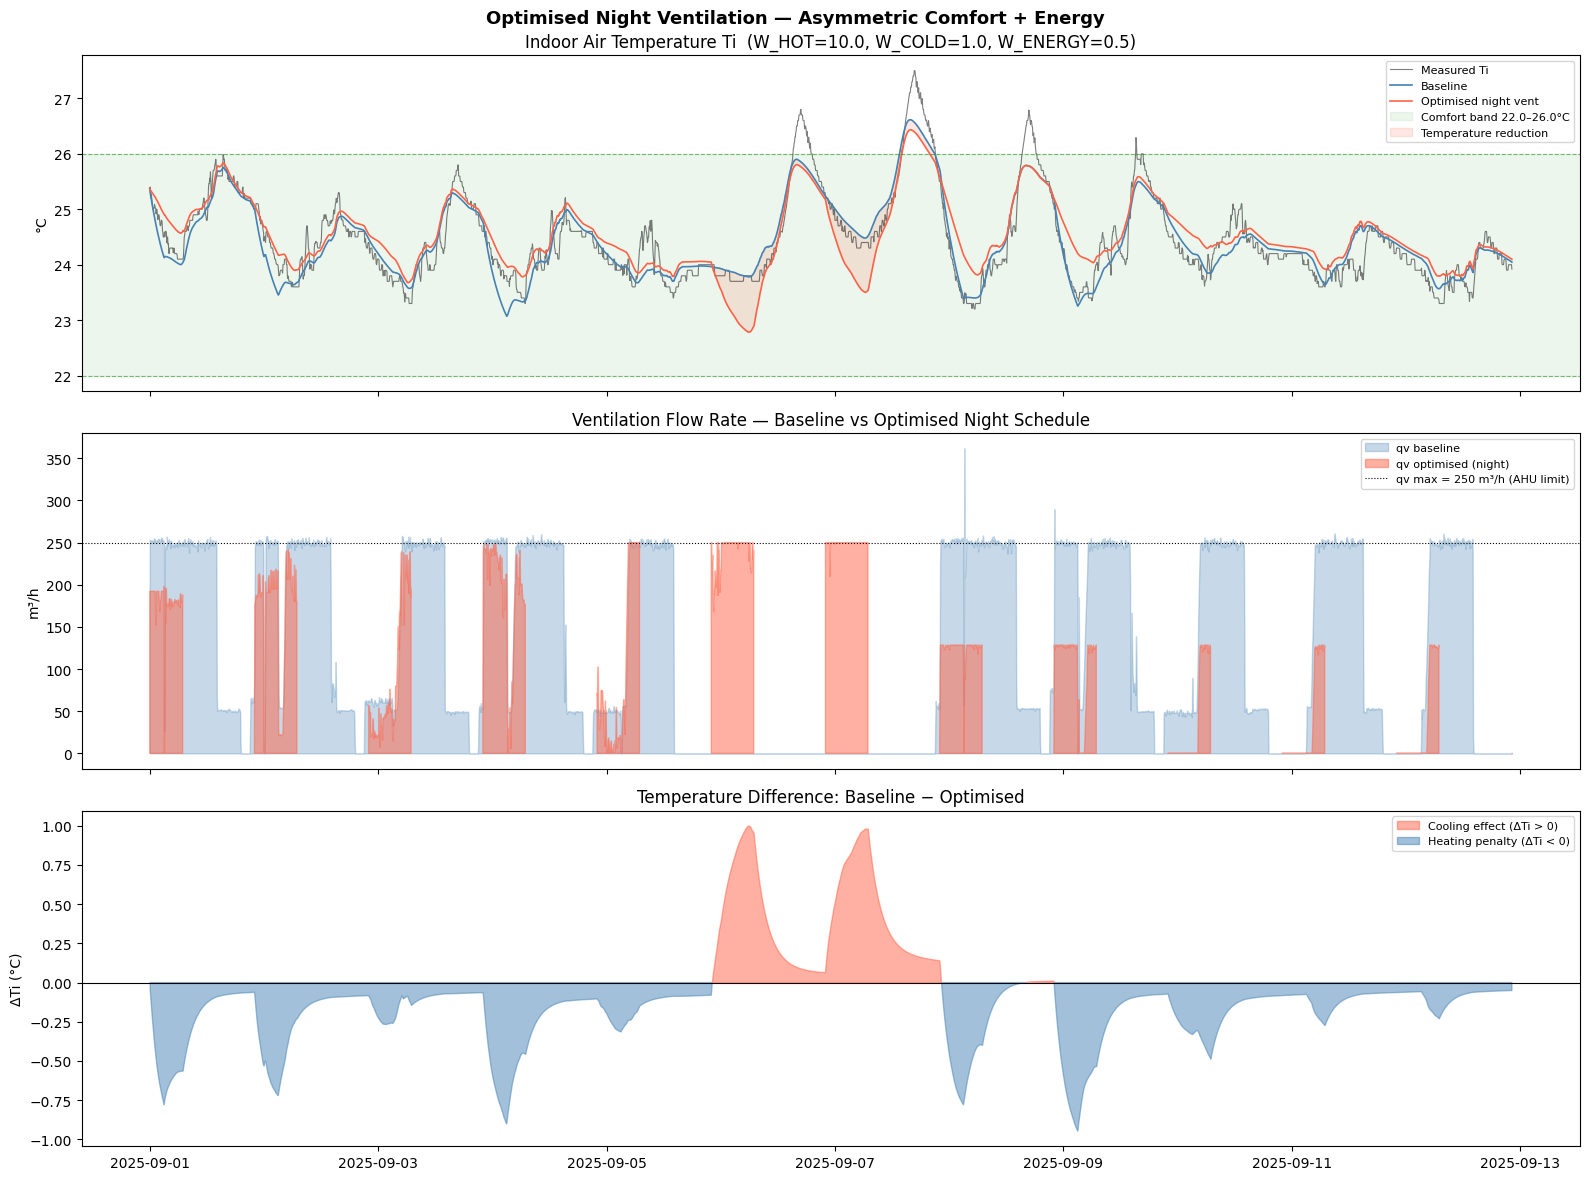

In [17]:
from scipy.optimize import minimize
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ════════════════════════════════════════════════════════════════════════════
#  CONFIG
# ════════════════════════════════════════════════════════════════════════════
T_occ_min   = 22.0
T_occ_max   = 26.0
OCC_START   = 8
OCC_END     = 18
NIGHT_START = 22
NIGHT_STOP  = 7

SFP         = 1.5      # W/(L/s) — specific fan power, SET FROM AHU DATASHEET
P_ELEC      = 1.493    # DKK/kWh — Danish commercial all-in tariff, DK2 zone
                       # Source: GlobalPetrolPrices.com (June 2025)
                       # https://www.globalpetrolprices.com/Denmark/electricity_prices/
                       # Note: spot-only price was ~0.62 DKK/kWh in Sept 2025 (DK2)
                       # All-in tariff used here as building pays full commercial rate

QV_MAX      = 250.0    # m³/h — from AHU datasheet
QV_MIN      = 0.0

W_HOT       = 10.0
W_COLD      = 1.0
W_ENERGY    = 0.5

# ════════════════════════════════════════════════════════════════════════════
#  BUILD NIGHT STEP INDEX
# ════════════════════════════════════════════════════════════════════════════
index  = X_train.index
hours  = np.array([t.hour + t.minute / 60.0 for t in index])

if NIGHT_START > NIGHT_STOP:
    night_mask = (hours >= NIGHT_START) | (hours < NIGHT_STOP)
else:
    night_mask = (hours >= NIGHT_START) & (hours < NIGHT_STOP)

occ_mask      = (hours >= OCC_START) & (hours < OCC_END)
night_indices = np.where(night_mask)[0]
n_night       = len(night_indices)
dt_h          = (index[1] - index[0]).seconds / 3600.0

print(f"Night steps to optimise : {n_night}")
print(f"qv bounds               : [{QV_MIN:.0f}, {QV_MAX:.0f}] m³/h")

# ════════════════════════════════════════════════════════════════════════════
#  OBJECTIVE FUNCTION
# ════════════════════════════════════════════════════════════════════════════
def objective(qv_night_vec):
    X_mod  = X_train.copy()
    Ta_arr = np.asarray(X_train['Ta'], dtype=float)
    X_mod.iloc[night_indices, X_mod.columns.get_loc('qv')]   = qv_night_vec
    X_mod.iloc[night_indices, X_mod.columns.get_loc('Tsup')] = Ta_arr[night_indices]

    result = simulate_night_vent_scenario(
        fitted_params, X_mod, N_hist,
        night_start_hour=0, night_stop_hour=0,
        qv_night=0,
        rec_duration=rec_duration,
        Ti_init=Ti_init, Tm_init=Tm_init, c_init=c_init
    )

    Ti     = result['Ti'].values
    Ti_occ = Ti[occ_mask]

    overheat   = np.maximum(0.0, Ti_occ - T_occ_max) ** 2
    undershoot = np.maximum(0.0, T_occ_min - Ti_occ) ** 2
    J_comfort  = (W_HOT * overheat.sum() + W_COLD * undershoot.sum()) * dt_h

    qv_ls    = qv_night_vec / 3.6        # m³/h → L/s
    P_fan_kW = qv_ls * SFP / 1000.0     # kW
    J_energy = W_ENERGY * np.sum(P_fan_kW * P_ELEC * dt_h)   # DKK

    return J_comfort + J_energy

# ════════════════════════════════════════════════════════════════════════════
#  INITIAL GUESS + BOUNDS
# ════════════════════════════════════════════════════════════════════════════
qv_arr = np.asarray(X_train['qv'], dtype=float)
x0     = qv_arr[night_indices].copy()
bounds = [(QV_MIN, QV_MAX)] * n_night

print("Running optimisation...")
result_opt = minimize(
    objective, x0,
    method='L-BFGS-B',
    bounds=bounds,
    options={'maxiter': 300, 'ftol': 1e-9, 'gtol': 1e-6, 'disp': True}
)

qv_opt = result_opt.x
print(f"\nOptimisation converged : {result_opt.success}")
print(f"Final cost             : {result_opt.fun:.4f}")

# ════════════════════════════════════════════════════════════════════════════
#  RUN OPTIMISED SCENARIO
# ════════════════════════════════════════════════════════════════════════════
X_opt = X_train.copy()
X_opt.iloc[night_indices, X_opt.columns.get_loc('qv')]   = qv_opt
X_opt.iloc[night_indices, X_opt.columns.get_loc('Tsup')] = \
    np.asarray(X_train['Ta'], dtype=float)[night_indices]

optimised = simulate_night_vent_scenario(
    fitted_params, X_opt, N_hist,
    night_start_hour=0, night_stop_hour=0,
    qv_night=0,
    rec_duration=rec_duration,
    Ti_init=Ti_init, Tm_init=Tm_init, c_init=c_init
)

# ════════════════════════════════════════════════════════════════════════════
#  METRICS
# ════════════════════════════════════════════════════════════════════════════
m_base = comfort_metrics(baseline['Ti'],  X_train.index,
                         T_comfort_min=T_occ_min, T_comfort_max=T_occ_max)
m_opt  = comfort_metrics(optimised['Ti'], X_train.index,
                         T_comfort_min=T_occ_min, T_comfort_max=T_occ_max)

print(f"\n{'Metric':<25} {'Baseline':>12} {'Optimised':>12}")
print("-" * 52)
for k in ['dh_above', 'dh_below', 'pct_ok', 'Ti_peak', 'Ti_mean']:
    unit = ' °Ch' if 'dh' in k else (' %' if 'pct' in k else ' °C')
    print(f"{k:<25} {m_base[k]:>12.2f}{unit}   {m_opt[k]:>12.2f}{unit}")

qv_opt_full                = qv_arr.copy()
qv_opt_full[night_indices] = qv_opt
P_fan_baseline_kW = (qv_arr[night_mask]      / 3.6) * SFP / 1000.0
P_fan_opt_kW      = (qv_opt_full[night_mask] / 3.6) * SFP / 1000.0
cost_baseline     = np.sum(P_fan_baseline_kW * P_ELEC * dt_h)
cost_opt          = np.sum(P_fan_opt_kW      * P_ELEC * dt_h)
print(f"\n  Night fan energy cost — Baseline : {cost_baseline:.3f} DKK")
print(f"  Night fan energy cost — Optimised: {cost_opt:.3f} DKK")
print(f"  Saving                           : {cost_baseline - cost_opt:.3f} DKK")
print(f"\n  Weights used: W_HOT={W_HOT}, W_COLD={W_COLD}, W_ENERGY={W_ENERGY}")

# ════════════════════════════════════════════════════════════════════════════
#  PLOT
# ════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)
fig.suptitle('Optimised Night Ventilation — Asymmetric Comfort + Energy',
             fontsize=13, fontweight='bold')

ax = axes[0]
ax.plot(index, y_train,         color='black',     lw=0.8, alpha=0.5, label='Measured Ti')
ax.plot(index, baseline['Ti'],  color='steelblue', lw=1.2, label='Baseline')
ax.plot(index, optimised['Ti'], color='tomato',    lw=1.2, label='Optimised night vent')
ax.axhspan(T_occ_min, T_occ_max, alpha=0.07, color='green',
           label=f'Comfort band {T_occ_min}–{T_occ_max}°C')
ax.axhline(T_occ_max, color='green', lw=0.8, ls='--', alpha=0.5)
ax.axhline(T_occ_min, color='green', lw=0.8, ls='--', alpha=0.5)
ax.fill_between(index,
    baseline['Ti'], optimised['Ti'],
    where=(baseline['Ti'] > optimised['Ti']),
    alpha=0.15, color='tomato', label='Temperature reduction')
ax.set_ylabel('°C')
ax.legend(fontsize=8)
ax.set_title(f'Indoor Air Temperature Ti  '
             f'(W_HOT={W_HOT}, W_COLD={W_COLD}, W_ENERGY={W_ENERGY})')

ax = axes[1]
ax.fill_between(index, qv_arr,      0, alpha=0.3, color='steelblue', label='qv baseline')
ax.fill_between(index, qv_opt_full, 0,
    where=night_mask, alpha=0.5, color='tomato', label='qv optimised (night)')
ax.axhline(QV_MAX, color='black', lw=0.8, ls=':',
           label=f'qv max = {QV_MAX:.0f} m³/h (AHU limit)')
ax.set_ylabel('m³/h')
ax.legend(fontsize=8)
ax.set_title('Ventilation Flow Rate — Baseline vs Optimised Night Schedule')

ax = axes[2]
delta = baseline['Ti'].values - optimised['Ti'].values
ax.fill_between(index, delta, 0,
    where=(delta > 0), color='tomato',    alpha=0.5, label='Cooling effect (ΔTi > 0)')
ax.fill_between(index, delta, 0,
    where=(delta < 0), color='steelblue', alpha=0.5, label='Heating penalty (ΔTi < 0)')
ax.axhline(0, color='black', lw=0.8)
ax.set_ylabel('ΔTi (°C)')
ax.legend(fontsize=8)
ax.set_title('Temperature Difference: Baseline − Optimised')

plt.tight_layout()
plt.savefig('night_vent_optimised.png', dpi=150, bbox_inches='tight')
plt.show()


## Optimize in category I, no energy optimization

Night steps to optimise (weekdays only) : 1056
qv bounds                               : [0, 250] m³/h
Target                                  : EN 16798-1 Category I  [23.5–25.5°C]
Running optimisation...

Optimisation converged : False
Final cost             : 56.2569

Metric                             Baseline    Optimised
---------------------------------------------------------
dh_above                               7.05 °Ch           7.91 °Ch
dh_below                               0.00 °Ch           0.00 °Ch
pct_ok (Cat. I)                       86.60 %          84.31 %
Ti_peak                               26.61 °C          26.64 °C
Ti_mean                               24.64 °C          24.71 °C
pct_ok (Cat. II)                      96.32 %          96.25 %

  [Info only — not in optimisation]
  Night fan energy cost — Baseline : 8.743 DKK
  Night fan energy cost — Optimised: 8.702 DKK
  Extra cost vs baseline           : -0.042 DKK


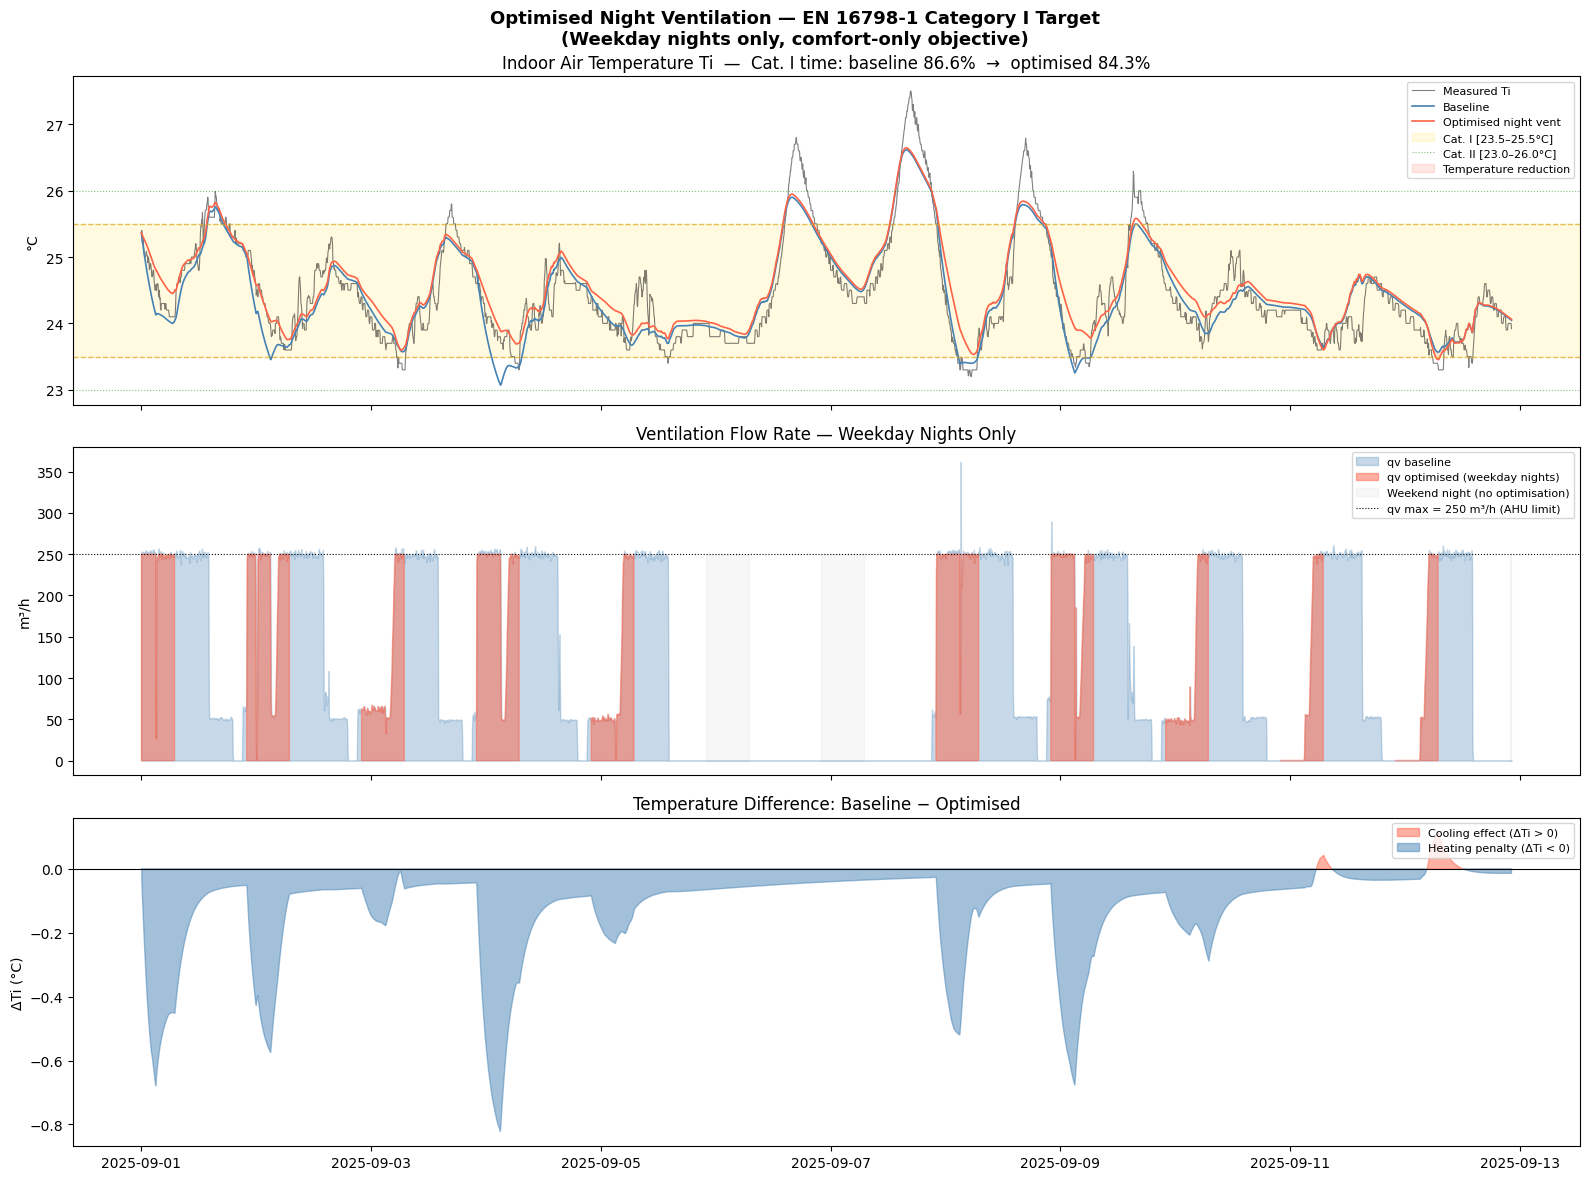

In [18]:
from scipy.optimize import minimize
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ════════════════════════════════════════════════════════════════════════════
#  CONFIG
# ════════════════════════════════════════════════════════════════════════════
# EN 16798-1 Category I — offices, summer (operative temperature)
T_cat1_min  = 23.5    # °C — Category I lower bound
T_cat1_max  = 25.5    # °C — Category I upper bound
T_cat2_min  = 23.0    # °C — Category II lower bound (for reference)
T_cat2_max  = 26.0    # °C — Category II upper bound (for reference)

OCC_START   = 8
OCC_END     = 18
NIGHT_START = 22
NIGHT_STOP  = 7

SFP         = 1.5     # W/(L/s) — specific fan power, SET FROM AHU DATASHEET
P_ELEC      = 1.493   # DKK/kWh — Danish commercial all-in tariff, DK2 zone
                      # Source: GlobalPetrolPrices.com (June 2025)
                      # https://www.globalpetrolprices.com/Denmark/electricity_prices/
                      # Note: spot-only price was ~0.62 DKK/kWh in Sept 2025 (DK2)
                      # All-in tariff used here as building pays full commercial rate

QV_MAX      = 250.0   # m³/h — from AHU datasheet
QV_MIN      = 0.0

# Pure comfort weights — no energy term
W_HOT       = 10.0    # above Category I upper bound
W_COLD      = 1.0     # below Category I lower bound (light — pre-cooling is desired)

# ════════════════════════════════════════════════════════════════════════════
#  BUILD NIGHT STEP INDEX — weekdays only
# ════════════════════════════════════════════════════════════════════════════
index    = X_train.index
hours    = np.array([t.hour + t.minute / 60.0 for t in index])
weekdays = np.array([t.weekday() for t in index])   # 0=Mon … 4=Fri, 5=Sat, 6=Sun

if NIGHT_START > NIGHT_STOP:   # crosses midnight
    night_time_mask = (hours >= NIGHT_START) | (hours < NIGHT_STOP)
else:
    night_time_mask = (hours >= NIGHT_START) & (hours < NIGHT_STOP)

# Night ventilation only on weekday nights (Sun 22:00–Mon 07:00 counts,
# Fri 22:00–Sat 07:00 does NOT, Sat 22:00–Sun 07:00 does NOT)
# A night step is "weekday night" if the NEXT morning is a weekday
def next_morning_is_weekday(t):
    """True if the morning following this night step is Mon–Fri."""
    import pandas as _pd
    # night after 22:00 → next day; night before 07:00 → same calendar day
    if t.hour >= NIGHT_START:
        next_day = t + _pd.Timedelta(days=1)
    else:
        next_day = t
    return next_day.weekday() < 5   # Mon=0 … Fri=4

weekday_night_mask = night_time_mask & np.array(
    [next_morning_is_weekday(t) for t in index]
)

occ_mask      = (hours >= OCC_START) & (hours < OCC_END)
night_indices = np.where(weekday_night_mask)[0]
n_night       = len(night_indices)
dt_h          = (index[1] - index[0]).seconds / 3600.0

print(f"Night steps to optimise (weekdays only) : {n_night}")
print(f"qv bounds                               : [{QV_MIN:.0f}, {QV_MAX:.0f}] m³/h")
print(f"Target                                  : EN 16798-1 Category I  "
      f"[{T_cat1_min}–{T_cat1_max}°C]")

# ════════════════════════════════════════════════════════════════════════════
#  OBJECTIVE — comfort only, Category I target
# ════════════════════════════════════════════════════════════════════════════
def objective(qv_night_vec):
    X_mod  = X_train.copy()
    Ta_arr = np.asarray(X_train['Ta'], dtype=float)
    X_mod.iloc[night_indices, X_mod.columns.get_loc('qv')]   = qv_night_vec
    X_mod.iloc[night_indices, X_mod.columns.get_loc('Tsup')] = Ta_arr[night_indices]

    result = simulate_night_vent_scenario(
        fitted_params, X_mod, N_hist,
        night_start_hour=0, night_stop_hour=0,
        qv_night=0,
        rec_duration=rec_duration,
        Ti_init=Ti_init, Tm_init=Tm_init, c_init=c_init
    )

    Ti     = result['Ti'].values
    Ti_occ = Ti[occ_mask]

    # Asymmetric penalty around Category I band
    # Above 25.5°C: heavily penalised — push down into band
    # Below 23.5°C: lightly penalised — pre-cooling below band is acceptable
    # Inside [23.5, 25.5]: zero cost
    overheat   = np.maximum(0.0, Ti_occ - T_cat1_max) ** 2
    undershoot = np.maximum(0.0, T_cat1_min - Ti_occ) ** 2
    J_comfort  = (W_HOT * overheat.sum() + W_COLD * undershoot.sum()) * dt_h

    return J_comfort   # ← no energy term

# ════════════════════════════════════════════════════════════════════════════
#  INITIAL GUESS + BOUNDS
# ════════════════════════════════════════════════════════════════════════════
qv_arr = np.asarray(X_train['qv'], dtype=float)
x0     = qv_arr[night_indices].copy()
bounds = [(QV_MIN, QV_MAX)] * n_night

print("Running optimisation...")
result_opt = minimize(
    objective, x0,
    method='L-BFGS-B',
    bounds=bounds,
    options={'maxiter': 300, 'ftol': 1e-9, 'gtol': 1e-6, 'disp': True}
)

qv_opt = result_opt.x
print(f"\nOptimisation converged : {result_opt.success}")
print(f"Final cost             : {result_opt.fun:.4f}")

# ════════════════════════════════════════════════════════════════════════════
#  RUN OPTIMISED SCENARIO
# ════════════════════════════════════════════════════════════════════════════
X_opt = X_train.copy()
X_opt.iloc[night_indices, X_opt.columns.get_loc('qv')]   = qv_opt
X_opt.iloc[night_indices, X_opt.columns.get_loc('Tsup')] = \
    np.asarray(X_train['Ta'], dtype=float)[night_indices]

optimised = simulate_night_vent_scenario(
    fitted_params, X_opt, N_hist,
    night_start_hour=0, night_stop_hour=0,
    qv_night=0,
    rec_duration=rec_duration,
    Ti_init=Ti_init, Tm_init=Tm_init, c_init=c_init
)

# ════════════════════════════════════════════════════════════════════════════
#  METRICS — report Category I and II separately
# ════════════════════════════════════════════════════════════════════════════
def pct_in_category(Ti_series, index, T_min, T_max,
                    occ_start=OCC_START, occ_end=OCC_END):
    h   = np.array([t.hour + t.minute / 60.0 for t in index])
    msk = (h >= occ_start) & (h < occ_end)
    Ti  = np.asarray(Ti_series)[msk]
    return float(np.mean((Ti >= T_min) & (Ti <= T_max)) * 100)

m_base = comfort_metrics(baseline['Ti'],  X_train.index,
                         T_comfort_min=T_cat1_min, T_comfort_max=T_cat1_max)
m_opt  = comfort_metrics(optimised['Ti'], X_train.index,
                         T_comfort_min=T_cat1_min, T_comfort_max=T_cat1_max)

print(f"\n{'Metric':<30} {'Baseline':>12} {'Optimised':>12}")
print("-" * 57)
for k in ['dh_above', 'dh_below', 'pct_ok', 'Ti_peak', 'Ti_mean']:
    unit = ' °Ch' if 'dh' in k else (' %' if 'pct' in k else ' °C')
    label = k if k != 'pct_ok' else 'pct_ok (Cat. I)'
    print(f"{label:<30} {m_base[k]:>12.2f}{unit}   {m_opt[k]:>12.2f}{unit}")

pct2_base = pct_in_category(baseline['Ti'],  X_train.index, T_cat2_min, T_cat2_max)
pct2_opt  = pct_in_category(optimised['Ti'], X_train.index, T_cat2_min, T_cat2_max)
print(f"{'pct_ok (Cat. II)':<30} {pct2_base:>12.2f} %   {pct2_opt:>12.2f} %")

# Energy cost — informational only, not in optimisation
qv_opt_full                = qv_arr.copy()
qv_opt_full[night_indices] = qv_opt
P_fan_baseline_kW = (qv_arr[weekday_night_mask]      / 3.6) * SFP / 1000.0
P_fan_opt_kW      = (qv_opt_full[weekday_night_mask] / 3.6) * SFP / 1000.0
cost_baseline     = np.sum(P_fan_baseline_kW * P_ELEC * dt_h)
cost_opt          = np.sum(P_fan_opt_kW      * P_ELEC * dt_h)
print(f"\n  [Info only — not in optimisation]")
print(f"  Night fan energy cost — Baseline : {cost_baseline:.3f} DKK")
print(f"  Night fan energy cost — Optimised: {cost_opt:.3f} DKK")
print(f"  Extra cost vs baseline           : {cost_opt - cost_baseline:.3f} DKK")

# ════════════════════════════════════════════════════════════════════════════
#  PLOT
# ════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)
fig.suptitle('Optimised Night Ventilation — EN 16798-1 Category I Target\n'
             '(Weekday nights only, comfort-only objective)',
             fontsize=13, fontweight='bold')

# 1. Ti
ax = axes[0]
ax.plot(index, y_train,         color='black',     lw=0.8, alpha=0.5, label='Measured Ti')
ax.plot(index, baseline['Ti'],  color='steelblue', lw=1.2, label='Baseline')
ax.plot(index, optimised['Ti'], color='tomato',    lw=1.2, label='Optimised night vent')
# Category I band
ax.axhspan(T_cat1_min, T_cat1_max, alpha=0.12, color='gold',
           label=f'Cat. I [{T_cat1_min}–{T_cat1_max}°C]')
ax.axhline(T_cat1_max, color='goldenrod', lw=1.0, ls='--', alpha=0.7)
ax.axhline(T_cat1_min, color='goldenrod', lw=1.0, ls='--', alpha=0.7)
# Category II band outline
ax.axhline(T_cat2_max, color='green', lw=0.8, ls=':', alpha=0.5,
           label=f'Cat. II [{T_cat2_min}–{T_cat2_max}°C]')
ax.axhline(T_cat2_min, color='green', lw=0.8, ls=':', alpha=0.5)
ax.fill_between(index,
    baseline['Ti'], optimised['Ti'],
    where=(baseline['Ti'] > optimised['Ti']),
    alpha=0.15, color='tomato', label='Temperature reduction')
ax.set_ylabel('°C')
ax.legend(fontsize=8)
ax.set_title(f'Indoor Air Temperature Ti  —  '
             f'Cat. I time: baseline {m_base["pct_ok"]:.1f}%  →  '
             f'optimised {m_opt["pct_ok"]:.1f}%')

# 2. qv schedule
ax = axes[1]
ax.fill_between(index, qv_arr,      0, alpha=0.3, color='steelblue', label='qv baseline')
ax.fill_between(index, qv_opt_full, 0,
    where=weekday_night_mask, alpha=0.5, color='tomato',
    label='qv optimised (weekday nights)')
# Shade weekend nights to show they are excluded
weekend_night_mask = night_time_mask & ~weekday_night_mask
ax.fill_between(index, QV_MAX, 0,
    where=weekend_night_mask, alpha=0.06, color='grey',
    label='Weekend night (no optimisation)')
ax.axhline(QV_MAX, color='black', lw=0.8, ls=':',
           label=f'qv max = {QV_MAX:.0f} m³/h (AHU limit)')
ax.set_ylabel('m³/h')
ax.legend(fontsize=8)
ax.set_title('Ventilation Flow Rate — Weekday Nights Only')

# 3. ΔTi
ax = axes[2]
delta = baseline['Ti'].values - optimised['Ti'].values
ax.fill_between(index, delta, 0,
    where=(delta > 0), color='tomato',    alpha=0.5, label='Cooling effect (ΔTi > 0)')
ax.fill_between(index, delta, 0,
    where=(delta < 0), color='steelblue', alpha=0.5, label='Heating penalty (ΔTi < 0)')
ax.axhline(0, color='black', lw=0.8)
ax.set_ylabel('ΔTi (°C)')
ax.legend(fontsize=8)
ax.set_title('Temperature Difference: Baseline − Optimised')

plt.tight_layout()
plt.savefig('night_vent_optimised_cat1.png', dpi=150, bbox_inches='tight')
plt.show()


## Simu plus rapide

Decision variables      : 11  (one qv per night, was ~1056)
qv bounds               : [0, 250] m³/h
Target                  : EN 16798-1 Category I [23.5–25.5°C]
Running optimisation...

Optimisation converged : False
Final cost             : 52.0854
Optimal qv per night   : [249.7  63.  250.   51.7   nan 250.  248.1  49.    0.    0.    nan] m³/h

Metric                             Baseline    Optimised
---------------------------------------------------------
dh_above                               7.05 °Ch           7.97 °Ch
dh_below                               0.00 °Ch           0.00 °Ch
Ti_peak                               26.61 °C          26.65 °C
Ti_mean                               24.64 °C          24.74 °C
pct_ok (Cat. I,  occ.)                86.60 %          84.44 %
pct_ok (Cat. II, occ.)                96.32 %          96.25 %

  [Info only — not in optimisation]
  Night fan energy cost — Baseline : 8.743 DKK
  Night fan energy cost — Optimised: 7.590 DKK
  Extra cost v

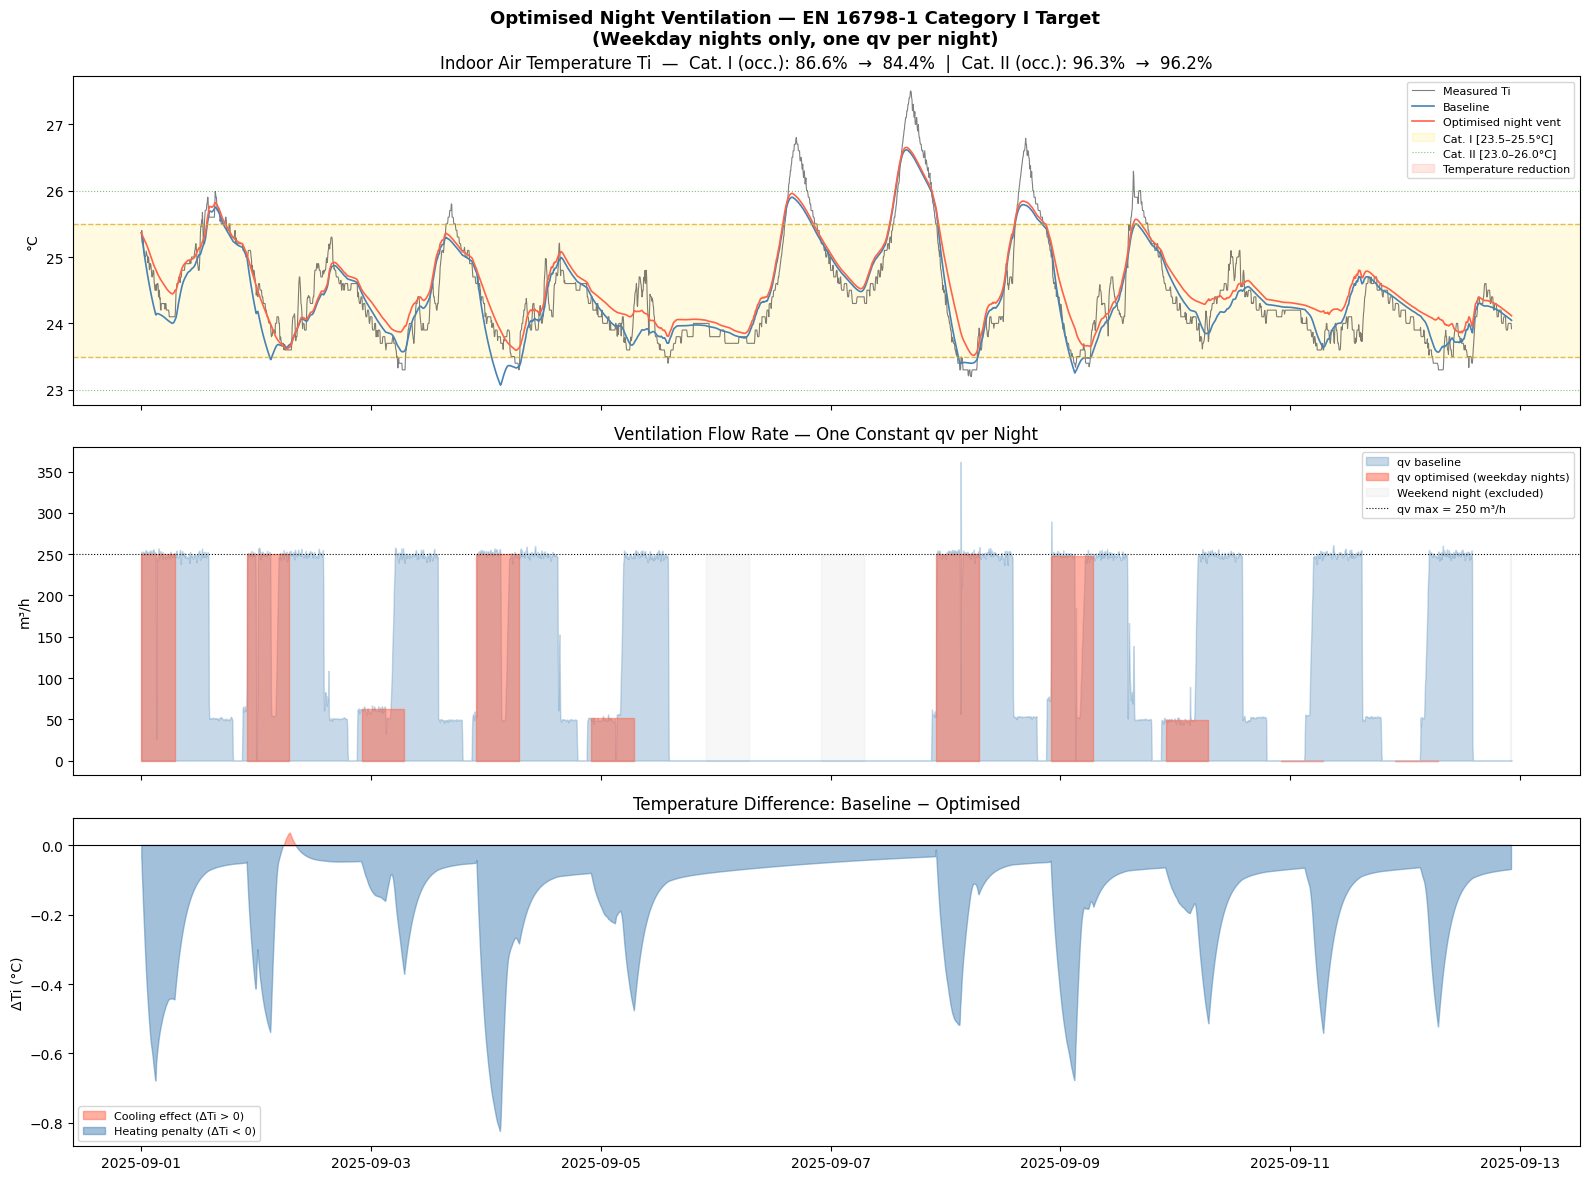

In [20]:
from scipy.optimize import minimize
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ════════════════════════════════════════════════════════════════════════════
#  CONFIG
# ════════════════════════════════════════════════════════════════════════════
T_cat1_min  = 23.5
T_cat1_max  = 25.5
T_cat2_min  = 23.0
T_cat2_max  = 26.0
OCC_START   = 8
OCC_END     = 18
NIGHT_START = 22
NIGHT_STOP  = 7


SFP         = 1.5
P_ELEC      = 1.493   # DKK/kWh — Danish commercial all-in tariff, DK2 zone
                      # Source: GlobalPetrolPrices.com (June 2025)
                      # [https://www.globalpetrolprices.com/Denmark/electricity_prices/](https://www.globalpetrolprices.com/Denmark/electricity_prices/)


QV_MAX      = 250.0
QV_MIN      = 0.0
W_HOT       = 10.0
W_COLD      = 1.0


# ════════════════════════════════════════════════════════════════════════════
#  MASKS & PRECOMPUTED ARRAYS  (outside objective — computed once)
# ════════════════════════════════════════════════════════════════════════════
index    = X_train.index
hours    = np.array([t.hour + t.minute / 60.0 for t in index])
dt_h     = (index[1] - index[0]).seconds / 3600.0


if NIGHT_START > NIGHT_STOP:
    night_time_mask = (hours >= NIGHT_START) | (hours < NIGHT_STOP)
else:
    night_time_mask = (hours >= NIGHT_START) & (hours < NIGHT_STOP)


def next_morning_is_weekday(t):
    next_day = t + pd.Timedelta(days=1) if t.hour >= NIGHT_START else t
    return next_day.weekday() < 5


weekday_night_mask = night_time_mask & np.array(
    [next_morning_is_weekday(t) for t in index]
)
weekend_night_mask = night_time_mask & ~weekday_night_mask
occ_mask           = (hours >= OCC_START) & (hours < OCC_END)


# ── Precompute arrays once — avoids repeated DataFrame access ────────────────
qv_arr     = np.asarray(X_train['qv'],  dtype=float)
Ta_arr     = np.asarray(X_train['Ta'],  dtype=float)
Tsup_arr   = np.asarray(X_train['Tsup'], dtype=float)


# ── Key speedup: group night steps by calendar night ─────────────────────────
# Instead of 1 decision variable per timestep, use 1 per night
# Result: ~13 vars instead of ~1000 → ~100x fewer gradient evaluations
night_dates = pd.Series(index[weekday_night_mask]).dt.normalize().unique()
n_nights    = len(night_dates)


# Map each night step to its night index
night_step_indices = np.where(weekday_night_mask)[0]
step_to_night      = {}
for step_idx in night_step_indices:
    t = index[step_idx]
    cal_date = (t - pd.Timedelta(days=1)).normalize() if t.hour < NIGHT_START else t.normalize()
    night_num = np.searchsorted(night_dates, cal_date)
    step_to_night[step_idx] = night_num


print(f"Decision variables      : {n_nights}  (one qv per night, was ~{len(night_step_indices)})")
print(f"qv bounds               : [{QV_MIN:.0f}, {QV_MAX:.0f}] m³/h")
print(f"Target                  : EN 16798-1 Category I [{T_cat1_min}–{T_cat1_max}°C]")


# ════════════════════════════════════════════════════════════════════════════
#  FAST OBJECTIVE — numpy arrays only, no DataFrame copy
# ════════════════════════════════════════════════════════════════════════════
def build_X_mod(qv_per_night):
    """Build modified qv and Tsup arrays from one-per-night decision vars."""
    qv_mod   = qv_arr.copy()
    Tsup_mod = Tsup_arr.copy()
    for step_idx, night_num in step_to_night.items():
        qv_mod[step_idx]   = qv_per_night[night_num]
        Tsup_mod[step_idx] = Ta_arr[step_idx]   # free cooling
    return qv_mod, Tsup_mod


def objective(qv_per_night):
    qv_mod, Tsup_mod = build_X_mod(qv_per_night)


    X_mod = X_train.copy()
    X_mod['qv']   = qv_mod
    X_mod['Tsup'] = Tsup_mod


    result = simulate_night_vent_scenario(
        fitted_params, X_mod, N_hist,
        night_start_hour=0, night_stop_hour=0,
        qv_night=0,
        rec_duration=rec_duration,
        Ti_init=Ti_init, Tm_init=Tm_init, c_init=c_init
    )


    Ti     = result['Ti'].values
    Ti_occ = Ti[occ_mask]


    overheat   = np.maximum(0.0, Ti_occ - T_cat1_max) ** 2
    undershoot = np.maximum(0.0, T_cat1_min - Ti_occ) ** 2
    return (W_HOT * overheat.sum() + W_COLD * undershoot.sum()) * dt_h


# ════════════════════════════════════════════════════════════════════════════
#  INITIAL GUESS + BOUNDS
#  One value per night — initialise from median of measured night qv
# ════════════════════════════════════════════════════════════════════════════
x0 = np.array([
    float(np.median(qv_arr[
        [s for s, n in step_to_night.items() if n == i]
    ]))
    for i in range(n_nights)
])
bounds = [(QV_MIN, QV_MAX)] * n_nights


print("Running optimisation...")
result_opt = minimize(
    objective, x0,
    method='L-BFGS-B',
    bounds=bounds,
    options={'maxiter': 200, 'ftol': 1e-7, 'gtol': 1e-5, 'disp': True}
)


qv_opt_per_night = result_opt.x
print(f"\nOptimisation converged : {result_opt.success}")
print(f"Final cost             : {result_opt.fun:.4f}")
print(f"Optimal qv per night   : {np.round(qv_opt_per_night, 1)} m³/h")


# ════════════════════════════════════════════════════════════════════════════
#  RECONSTRUCT FULL QV ARRAY + RUN OPTIMISED SCENARIO
# ════════════════════════════════════════════════════════════════════════════
qv_opt_full, Tsup_opt_full = build_X_mod(qv_opt_per_night)


X_opt          = X_train.copy()
X_opt['qv']    = qv_opt_full
X_opt['Tsup']  = Tsup_opt_full


optimised = simulate_night_vent_scenario(
    fitted_params, X_opt, N_hist,
    night_start_hour=0, night_stop_hour=0,
    qv_night=0,
    rec_duration=rec_duration,
    Ti_init=Ti_init, Tm_init=Tm_init, c_init=c_init
)


# ════════════════════════════════════════════════════════════════════════════
#  METRICS
# ════════════════════════════════════════════════════════════════════════════
def pct_in_category(Ti_series, T_min, T_max):
    """% of OCCUPIED hours where Ti is within [T_min, T_max]."""
    Ti = np.asarray(Ti_series)[occ_mask]   # occupied hours only, reuse precomputed mask
    return float(np.mean((Ti >= T_min) & (Ti <= T_max)) * 100)


m_base = comfort_metrics(baseline['Ti'],  X_train.index,
                         T_comfort_min=T_cat1_min, T_comfort_max=T_cat1_max)
m_opt  = comfort_metrics(optimised['Ti'], X_train.index,
                         T_comfort_min=T_cat1_min, T_comfort_max=T_cat1_max)


# Occupied-hours-only % for both categories
pct1_base = pct_in_category(baseline['Ti'],  T_cat1_min, T_cat1_max)
pct1_opt  = pct_in_category(optimised['Ti'], T_cat1_min, T_cat1_max)
pct2_base = pct_in_category(baseline['Ti'],  T_cat2_min, T_cat2_max)
pct2_opt  = pct_in_category(optimised['Ti'], T_cat2_min, T_cat2_max)


print(f"\n{'Metric':<30} {'Baseline':>12} {'Optimised':>12}")
print("-" * 57)
for k in ['dh_above', 'dh_below', 'Ti_peak', 'Ti_mean']:   # pct_ok removed — replaced below
    unit  = ' °Ch' if 'dh' in k else ' °C'
    print(f"{k:<30} {m_base[k]:>12.2f}{unit}   {m_opt[k]:>12.2f}{unit}")

# Occupied-hours-only comfort percentages
print(f"{'pct_ok (Cat. I,  occ.)':<30} {pct1_base:>12.2f} %   {pct1_opt:>12.2f} %")
print(f"{'pct_ok (Cat. II, occ.)':<30} {pct2_base:>12.2f} %   {pct2_opt:>12.2f} %")


P_fan_baseline_kW = (qv_arr[weekday_night_mask]         / 3.6) * SFP / 1000.0
P_fan_opt_kW      = (qv_opt_full[weekday_night_mask]    / 3.6) * SFP / 1000.0
cost_baseline     = np.sum(P_fan_baseline_kW * P_ELEC * dt_h)
cost_opt          = np.sum(P_fan_opt_kW      * P_ELEC * dt_h)
print(f"\n  [Info only — not in optimisation]")
print(f"  Night fan energy cost — Baseline : {cost_baseline:.3f} DKK")
print(f"  Night fan energy cost — Optimised: {cost_opt:.3f} DKK")
print(f"  Extra cost vs baseline           : {cost_opt - cost_baseline:.3f} DKK")


# ════════════════════════════════════════════════════════════════════════════
#  PLOT
# ════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)
fig.suptitle('Optimised Night Ventilation — EN 16798-1 Category I Target\n'
             '(Weekday nights only, one qv per night)',
             fontsize=13, fontweight='bold')


ax = axes[0]
ax.plot(index, y_train,         color='black',     lw=0.8, alpha=0.5, label='Measured Ti')
ax.plot(index, baseline['Ti'],  color='steelblue', lw=1.2, label='Baseline')
ax.plot(index, optimised['Ti'], color='tomato',    lw=1.2, label='Optimised night vent')
ax.axhspan(T_cat1_min, T_cat1_max, alpha=0.12, color='gold',
           label=f'Cat. I [{T_cat1_min}–{T_cat1_max}°C]')
ax.axhline(T_cat1_max, color='goldenrod', lw=1.0, ls='--', alpha=0.7)
ax.axhline(T_cat1_min, color='goldenrod', lw=1.0, ls='--', alpha=0.7)
ax.axhline(T_cat2_max, color='green',     lw=0.8, ls=':', alpha=0.5,
           label=f'Cat. II [{T_cat2_min}–{T_cat2_max}°C]')
ax.axhline(T_cat2_min, color='green',     lw=0.8, ls=':', alpha=0.5)
ax.fill_between(index,
    baseline['Ti'], optimised['Ti'],
    where=(baseline['Ti'] > optimised['Ti']),
    alpha=0.15, color='tomato', label='Temperature reduction')
ax.set_ylabel('°C')
ax.legend(fontsize=8)
ax.set_title(f'Indoor Air Temperature Ti  —  '
             f'Cat. I (occ.): {pct1_base:.1f}%  →  {pct1_opt:.1f}%  |  '
             f'Cat. II (occ.): {pct2_base:.1f}%  →  {pct2_opt:.1f}%')


ax = axes[1]
ax.fill_between(index, qv_arr,      0, alpha=0.3, color='steelblue', label='qv baseline')
ax.fill_between(index, qv_opt_full, 0,
    where=weekday_night_mask, alpha=0.5, color='tomato',
    label='qv optimised (weekday nights)')
ax.fill_between(index, QV_MAX, 0,
    where=weekend_night_mask, alpha=0.06, color='grey',
    label='Weekend night (excluded)')
ax.axhline(QV_MAX, color='black', lw=0.8, ls=':',
           label=f'qv max = {QV_MAX:.0f} m³/h')
ax.set_ylabel('m³/h')
ax.legend(fontsize=8)
ax.set_title('Ventilation Flow Rate — One Constant qv per Night')


ax = axes[2]
delta = baseline['Ti'].values - optimised['Ti'].values
ax.fill_between(index, delta, 0,
    where=(delta > 0), color='tomato',    alpha=0.5, label='Cooling effect (ΔTi > 0)')
ax.fill_between(index, delta, 0,
    where=(delta < 0), color='steelblue', alpha=0.5, label='Heating penalty (ΔTi < 0)')
ax.axhline(0, color='black', lw=0.8)
ax.set_ylabel('ΔTi (°C)')
ax.legend(fontsize=8)
ax.set_title('Temperature Difference: Baseline − Optimised')


plt.tight_layout()
plt.savefig('night_vent_optimised_cat1.png', dpi=150, bbox_inches='tight')
plt.show()


## Optimization, baseline = no ventilation at all

Decision variables      : 11  (one qv per night, was ~1056)
qv bounds               : [0, 250] m³/h
Target                  : EN 16798-1 Category I [23.5–25.5°C]
Running optimisation...

Optimisation converged : False
Final cost             : 52.0854
Optimal qv per night   : [249.7  63.  250.   51.7   nan 250.  248.1  49.    0.    0.    nan] m³/h

Metric                         Baseline (qv=0)    Optimised
------------------------------------------------------------
dh_above                                 29.95 °Ch           7.97 °Ch
dh_below                                  0.00 °Ch           0.00 °Ch
Ti_peak                                  26.80 °C          26.65 °C
Ti_mean                                  25.52 °C          24.74 °C
pct_ok (Cat. I,  occ.)                   53.61 %          84.44 %
pct_ok (Cat. II, occ.)                   76.11 %          96.25 %

  [Info only — not in optimisation]
  Night fan energy cost — Baseline (qv=0) : 0.000 DKK
  Night fan energy cost — Opti

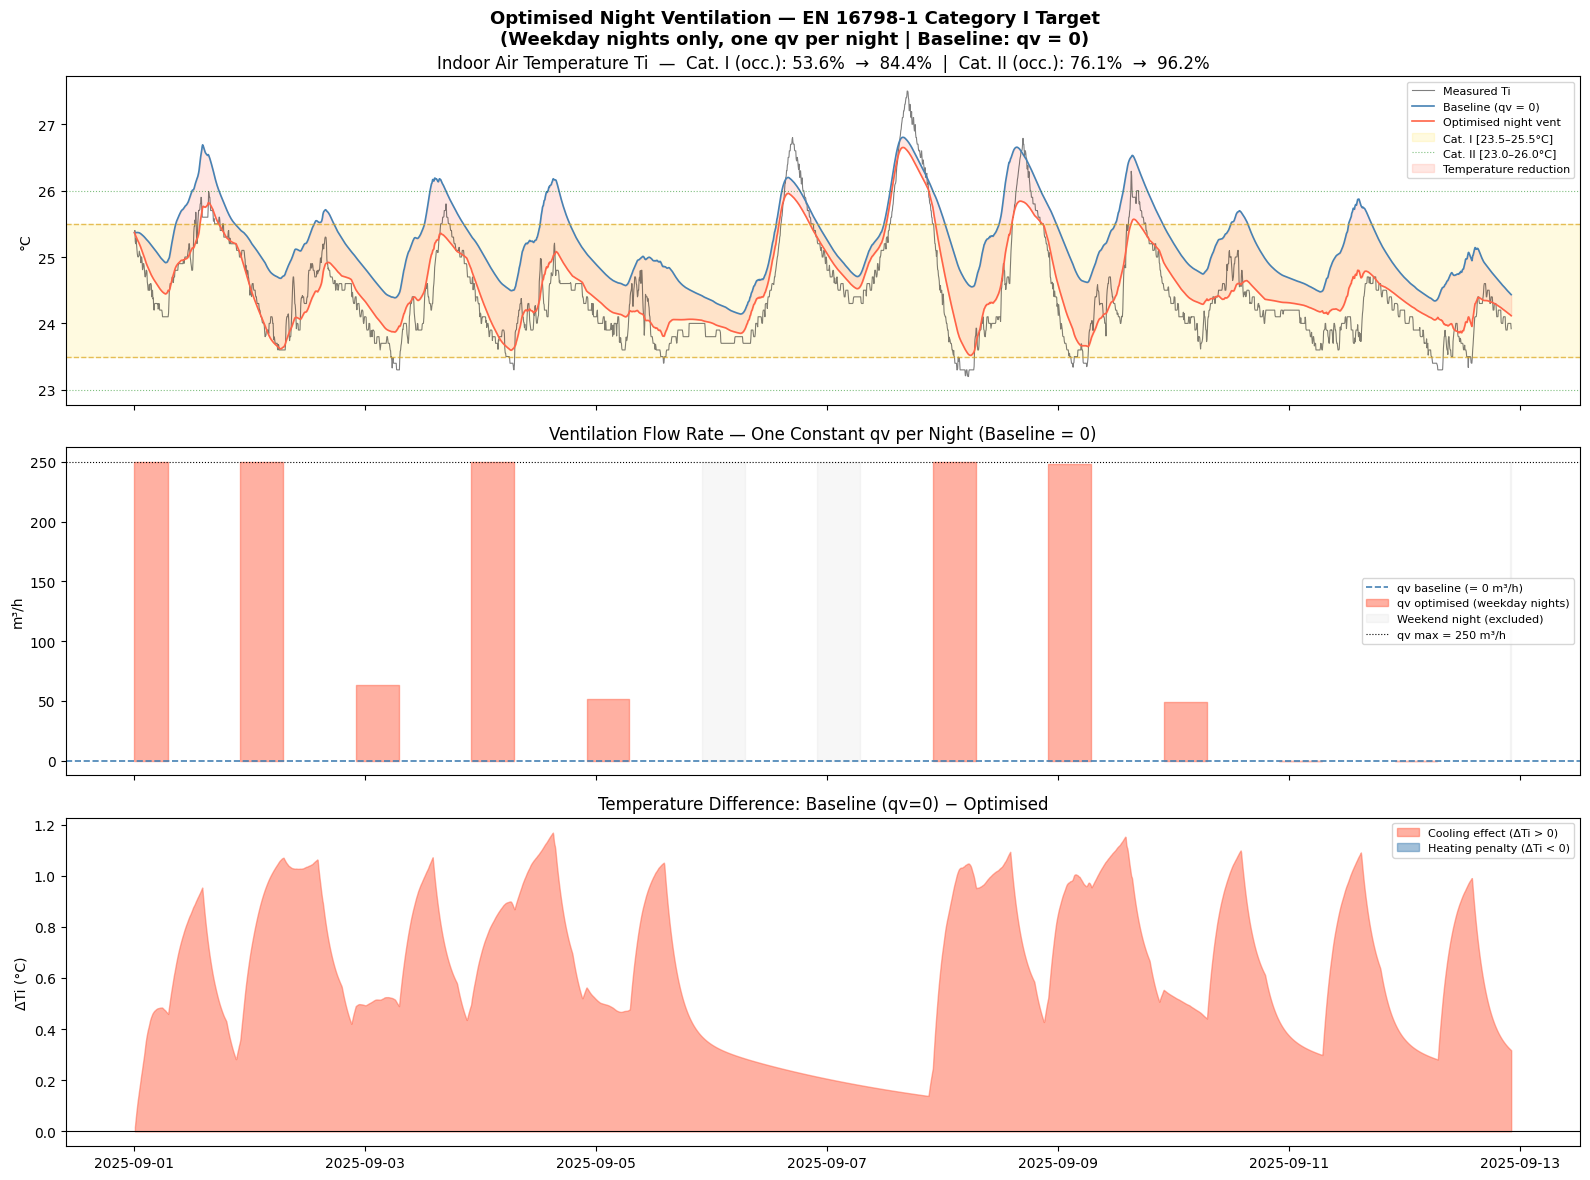

In [21]:
from scipy.optimize import minimize
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ════════════════════════════════════════════════════════════════════════════
#  CONFIG
# ════════════════════════════════════════════════════════════════════════════
T_cat1_min  = 23.5
T_cat1_max  = 25.5
T_cat2_min  = 23.0
T_cat2_max  = 26.0
OCC_START   = 8
OCC_END     = 18
NIGHT_START = 22
NIGHT_STOP  = 7


SFP         = 1.5
P_ELEC      = 1.493   # DKK/kWh — Danish commercial all-in tariff, DK2 zone


QV_MAX      = 250.0
QV_MIN      = 0.0
W_HOT       = 10.0
W_COLD      = 1.0


# ════════════════════════════════════════════════════════════════════════════
#  MASKS & PRECOMPUTED ARRAYS  (outside objective — computed once)
# ════════════════════════════════════════════════════════════════════════════
index    = X_train.index
hours    = np.array([t.hour + t.minute / 60.0 for t in index])
dt_h     = (index[1] - index[0]).seconds / 3600.0


if NIGHT_START > NIGHT_STOP:
    night_time_mask = (hours >= NIGHT_START) | (hours < NIGHT_STOP)
else:
    night_time_mask = (hours >= NIGHT_START) & (hours < NIGHT_STOP)


def next_morning_is_weekday(t):
    next_day = t + pd.Timedelta(days=1) if t.hour >= NIGHT_START else t
    return next_day.weekday() < 5


weekday_night_mask = night_time_mask & np.array(
    [next_morning_is_weekday(t) for t in index]
)
weekend_night_mask = night_time_mask & ~weekday_night_mask
occ_mask           = (hours >= OCC_START) & (hours < OCC_END)


# ── Precompute arrays once — avoids repeated DataFrame access ────────────────
qv_arr     = np.asarray(X_train['qv'],  dtype=float)
Ta_arr     = np.asarray(X_train['Ta'],  dtype=float)
Tsup_arr   = np.asarray(X_train['Tsup'], dtype=float)


# ── Key speedup: group night steps by calendar night ─────────────────────────
night_dates = pd.Series(index[weekday_night_mask]).dt.normalize().unique()
n_nights    = len(night_dates)


# Map each night step to its night index
night_step_indices = np.where(weekday_night_mask)[0]
step_to_night      = {}
for step_idx in night_step_indices:
    t = index[step_idx]
    cal_date = (t - pd.Timedelta(days=1)).normalize() if t.hour < NIGHT_START else t.normalize()
    night_num = np.searchsorted(night_dates, cal_date)
    step_to_night[step_idx] = night_num


print(f"Decision variables      : {n_nights}  (one qv per night, was ~{len(night_step_indices)})")
print(f"qv bounds               : [{QV_MIN:.0f}, {QV_MAX:.0f}] m³/h")
print(f"Target                  : EN 16798-1 Category I [{T_cat1_min}–{T_cat1_max}°C]")


# ════════════════════════════════════════════════════════════════════════════
#  BASELINE — zero ventilation everywhere
# ════════════════════════════════════════════════════════════════════════════
X_baseline         = X_train.copy()
X_baseline['qv']   = 0.0


baseline = simulate_night_vent_scenario(
    fitted_params, X_baseline, N_hist,
    night_start_hour=0, night_stop_hour=0,
    qv_night=0,
    rec_duration=rec_duration,
    Ti_init=Ti_init, Tm_init=Tm_init, c_init=c_init
)


# ════════════════════════════════════════════════════════════════════════════
#  FAST OBJECTIVE — numpy arrays only, no DataFrame copy
# ════════════════════════════════════════════════════════════════════════════
def build_X_mod(qv_per_night):
    """Build modified qv and Tsup arrays from one-per-night decision vars."""
    qv_mod   = qv_arr.copy()
    Tsup_mod = Tsup_arr.copy()
    for step_idx, night_num in step_to_night.items():
        qv_mod[step_idx]   = qv_per_night[night_num]
        Tsup_mod[step_idx] = Ta_arr[step_idx]   # free cooling
    return qv_mod, Tsup_mod


def objective(qv_per_night):
    qv_mod, Tsup_mod = build_X_mod(qv_per_night)


    X_mod = X_train.copy()
    X_mod['qv']   = qv_mod
    X_mod['Tsup'] = Tsup_mod


    result = simulate_night_vent_scenario(
        fitted_params, X_mod, N_hist,
        night_start_hour=0, night_stop_hour=0,
        qv_night=0,
        rec_duration=rec_duration,
        Ti_init=Ti_init, Tm_init=Tm_init, c_init=c_init
    )


    Ti     = result['Ti'].values
    Ti_occ = Ti[occ_mask]


    overheat   = np.maximum(0.0, Ti_occ - T_cat1_max) ** 2
    undershoot = np.maximum(0.0, T_cat1_min - Ti_occ) ** 2
    return (W_HOT * overheat.sum() + W_COLD * undershoot.sum()) * dt_h


# ════════════════════════════════════════════════════════════════════════════
#  INITIAL GUESS + BOUNDS
#  One value per night — initialise from median of measured night qv
# ════════════════════════════════════════════════════════════════════════════
x0 = np.array([
    float(np.median(qv_arr[
        [s for s, n in step_to_night.items() if n == i]
    ]))
    for i in range(n_nights)
])
bounds = [(QV_MIN, QV_MAX)] * n_nights


print("Running optimisation...")
result_opt = minimize(
    objective, x0,
    method='L-BFGS-B',
    bounds=bounds,
    options={'maxiter': 200, 'ftol': 1e-7, 'gtol': 1e-5, 'disp': True}
)


qv_opt_per_night = result_opt.x
print(f"\nOptimisation converged : {result_opt.success}")
print(f"Final cost             : {result_opt.fun:.4f}")
print(f"Optimal qv per night   : {np.round(qv_opt_per_night, 1)} m³/h")


# ════════════════════════════════════════════════════════════════════════════
#  RECONSTRUCT FULL QV ARRAY + RUN OPTIMISED SCENARIO
# ════════════════════════════════════════════════════════════════════════════
qv_opt_full, Tsup_opt_full = build_X_mod(qv_opt_per_night)


X_opt          = X_train.copy()
X_opt['qv']    = qv_opt_full
X_opt['Tsup']  = Tsup_opt_full


optimised = simulate_night_vent_scenario(
    fitted_params, X_opt, N_hist,
    night_start_hour=0, night_stop_hour=0,
    qv_night=0,
    rec_duration=rec_duration,
    Ti_init=Ti_init, Tm_init=Tm_init, c_init=c_init
)


# ════════════════════════════════════════════════════════════════════════════
#  METRICS
# ════════════════════════════════════════════════════════════════════════════
def pct_in_category(Ti_series, T_min, T_max):
    """% of OCCUPIED hours where Ti is within [T_min, T_max]."""
    Ti = np.asarray(Ti_series)[occ_mask]   # occupied hours only, reuse precomputed mask
    return float(np.mean((Ti >= T_min) & (Ti <= T_max)) * 100)


m_base = comfort_metrics(baseline['Ti'],  X_train.index,
                         T_comfort_min=T_cat1_min, T_comfort_max=T_cat1_max)
m_opt  = comfort_metrics(optimised['Ti'], X_train.index,
                         T_comfort_min=T_cat1_min, T_comfort_max=T_cat1_max)


# Occupied-hours-only % for both categories
pct1_base = pct_in_category(baseline['Ti'],  T_cat1_min, T_cat1_max)
pct1_opt  = pct_in_category(optimised['Ti'], T_cat1_min, T_cat1_max)
pct2_base = pct_in_category(baseline['Ti'],  T_cat2_min, T_cat2_max)
pct2_opt  = pct_in_category(optimised['Ti'], T_cat2_min, T_cat2_max)


print(f"\n{'Metric':<30} {'Baseline (qv=0)':>15} {'Optimised':>12}")
print("-" * 60)
for k in ['dh_above', 'dh_below', 'Ti_peak', 'Ti_mean']:
    unit  = ' °Ch' if 'dh' in k else ' °C'
    print(f"{k:<30} {m_base[k]:>15.2f}{unit}   {m_opt[k]:>12.2f}{unit}")

# Occupied-hours-only comfort percentages
print(f"{'pct_ok (Cat. I,  occ.)':<30} {pct1_base:>15.2f} %   {pct1_opt:>12.2f} %")
print(f"{'pct_ok (Cat. II, occ.)':<30} {pct2_base:>15.2f} %   {pct2_opt:>12.2f} %")


# Baseline has qv=0 everywhere so fan cost is zero
P_fan_opt_kW  = (qv_opt_full[weekday_night_mask] / 3.6) * SFP / 1000.0
cost_baseline = 0.0
cost_opt      = np.sum(P_fan_opt_kW * P_ELEC * dt_h)
print(f"\n  [Info only — not in optimisation]")
print(f"  Night fan energy cost — Baseline (qv=0) : {cost_baseline:.3f} DKK")
print(f"  Night fan energy cost — Optimised       : {cost_opt:.3f} DKK")
print(f"  Extra cost vs baseline                  : {cost_opt - cost_baseline:.3f} DKK")


# ════════════════════════════════════════════════════════════════════════════
#  PLOT
# ════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)
fig.suptitle('Optimised Night Ventilation — EN 16798-1 Category I Target\n'
             '(Weekday nights only, one qv per night | Baseline: qv = 0)',
             fontsize=13, fontweight='bold')


ax = axes[0]
ax.plot(index, y_train,         color='black',     lw=0.8, alpha=0.5, label='Measured Ti')
ax.plot(index, baseline['Ti'],  color='steelblue', lw=1.2, label='Baseline (qv = 0)')
ax.plot(index, optimised['Ti'], color='tomato',    lw=1.2, label='Optimised night vent')
ax.axhspan(T_cat1_min, T_cat1_max, alpha=0.12, color='gold',
           label=f'Cat. I [{T_cat1_min}–{T_cat1_max}°C]')
ax.axhline(T_cat1_max, color='goldenrod', lw=1.0, ls='--', alpha=0.7)
ax.axhline(T_cat1_min, color='goldenrod', lw=1.0, ls='--', alpha=0.7)
ax.axhline(T_cat2_max, color='green',     lw=0.8, ls=':', alpha=0.5,
           label=f'Cat. II [{T_cat2_min}–{T_cat2_max}°C]')
ax.axhline(T_cat2_min, color='green',     lw=0.8, ls=':', alpha=0.5)
ax.fill_between(index,
    baseline['Ti'], optimised['Ti'],
    where=(baseline['Ti'] > optimised['Ti']),
    alpha=0.15, color='tomato', label='Temperature reduction')
ax.set_ylabel('°C')
ax.legend(fontsize=8)
ax.set_title(f'Indoor Air Temperature Ti  —  '
             f'Cat. I (occ.): {pct1_base:.1f}%  →  {pct1_opt:.1f}%  |  '
             f'Cat. II (occ.): {pct2_base:.1f}%  →  {pct2_opt:.1f}%')


ax = axes[1]
# Baseline qv is 0 everywhere — no fill needed, just a reference line
ax.axhline(0, color='steelblue', lw=1.2, ls='--', label='qv baseline (= 0 m³/h)')
ax.fill_between(index, qv_opt_full, 0,
    where=weekday_night_mask, alpha=0.5, color='tomato',
    label='qv optimised (weekday nights)')
ax.fill_between(index, QV_MAX, 0,
    where=weekend_night_mask, alpha=0.06, color='grey',
    label='Weekend night (excluded)')
ax.axhline(QV_MAX, color='black', lw=0.8, ls=':',
           label=f'qv max = {QV_MAX:.0f} m³/h')
ax.set_ylabel('m³/h')
ax.legend(fontsize=8)
ax.set_title('Ventilation Flow Rate — One Constant qv per Night (Baseline = 0)')


ax = axes[2]
delta = baseline['Ti'].values - optimised['Ti'].values
ax.fill_between(index, delta, 0,
    where=(delta > 0), color='tomato',    alpha=0.5, label='Cooling effect (ΔTi > 0)')
ax.fill_between(index, delta, 0,
    where=(delta < 0), color='steelblue', alpha=0.5, label='Heating penalty (ΔTi < 0)')
ax.axhline(0, color='black', lw=0.8)
ax.set_ylabel('ΔTi (°C)')
ax.legend(fontsize=8)
ax.set_title('Temperature Difference: Baseline (qv=0) − Optimised')


plt.tight_layout()
plt.savefig('night_vent_optimised_cat1.png', dpi=150, bbox_inches='tight')
plt.show()


Decision variables      : 3436  (one qv per timestep)
qv bounds               : [0, 250] m³/h
Target                  : EN 16798-1 Category I [23.5–25.5°C]
Running optimisation (full-time ventilation control)...

Optimisation converged : False
Final cost             : 24.6963

Metric                         Baseline (qv=0)    Optimised
------------------------------------------------------------
dh_above                                 29.95 °Ch           0.91 °Ch
dh_below                                  0.00 °Ch           0.00 °Ch
Ti_peak                                  26.80 °C          25.72 °C
Ti_mean                                  25.52 °C          24.55 °C
pct_ok (Cat. I,  occ.)                   53.61 %          91.74 %
pct_ok (Cat. II, occ.)                   76.11 %         100.00 %

  [Info only — not in optimisation except fan_cost term]
  Fan energy cost — Baseline (qv=0) : 0.000 DKK
  Fan energy cost — Optimised       : 23.428 DKK
  Extra cost vs baseline            : 

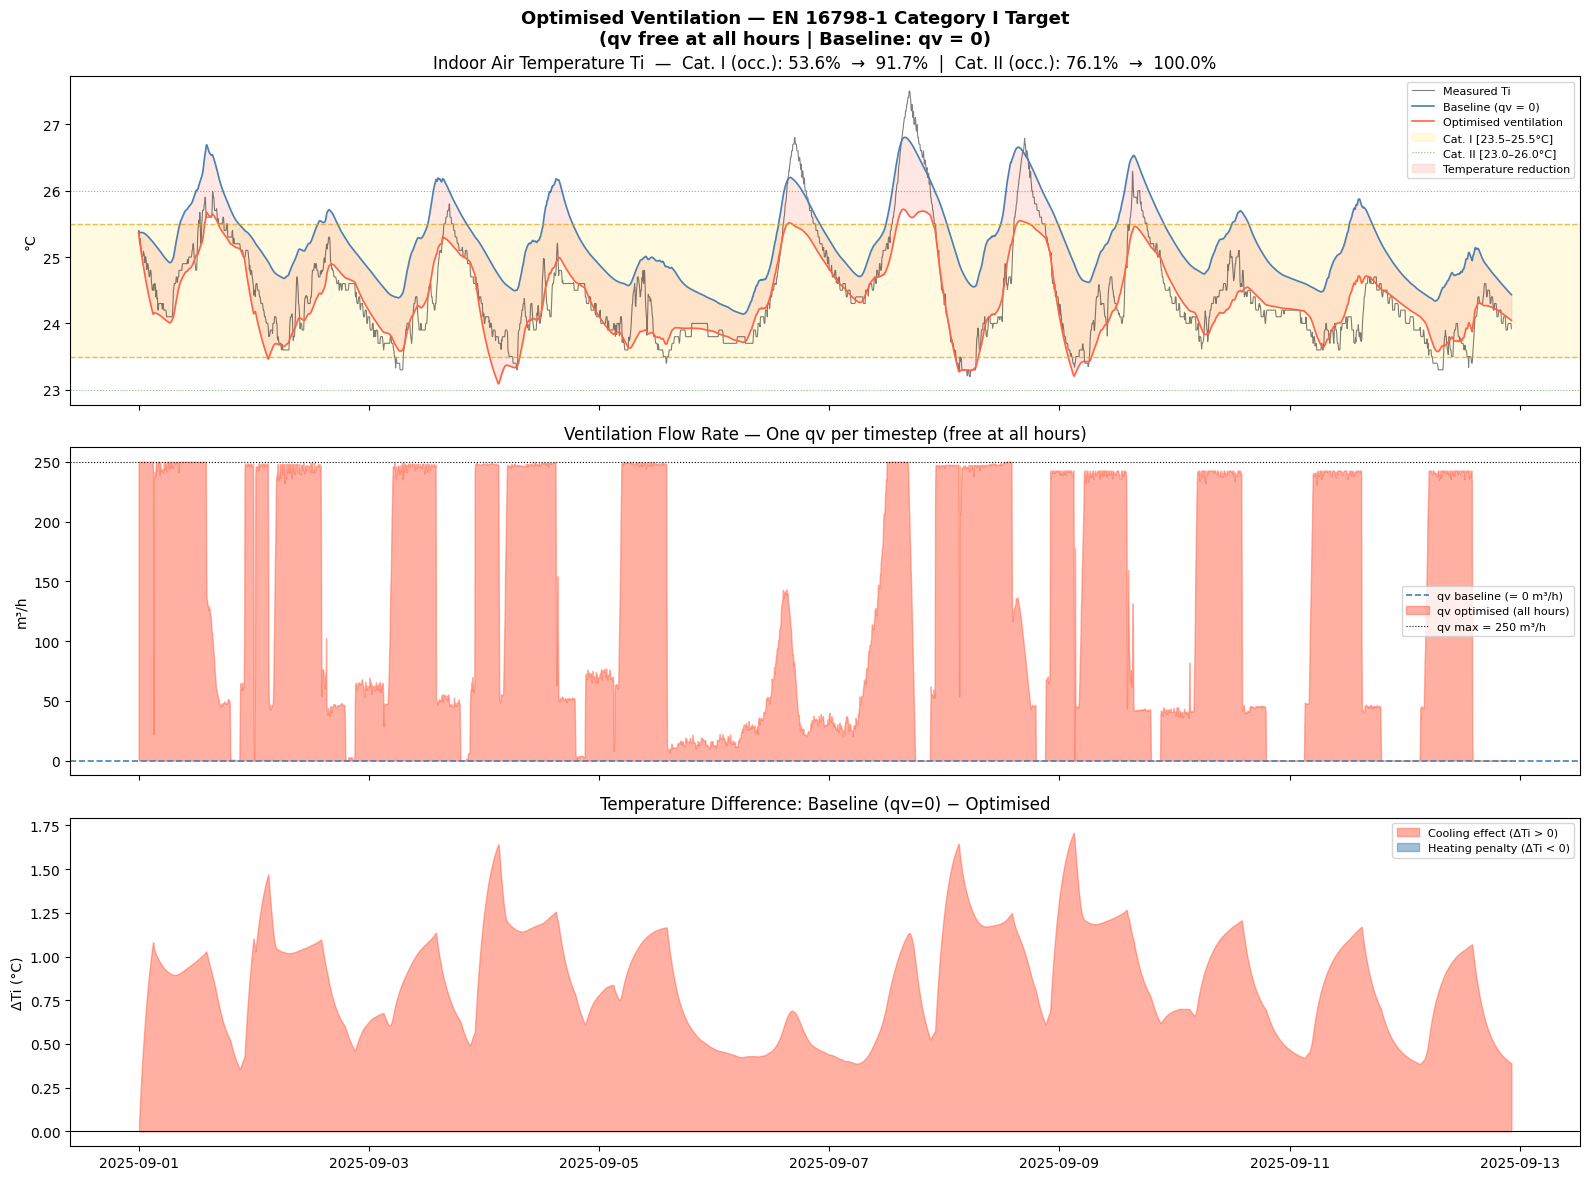

In [22]:
from scipy.optimize import minimize
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ════════════════════════════════════════════════════════════════════════════
#  CONFIG
# ════════════════════════════════════════════════════════════════════════════
T_cat1_min  = 23.5
T_cat1_max  = 25.5
T_cat2_min  = 23.0
T_cat2_max  = 26.0
OCC_START   = 8
OCC_END     = 18

SFP         = 1.5
P_ELEC      = 1.493   # DKK/kWh — Danish commercial all-in tariff, DK2 zone

QV_MAX      = 250.0
QV_MIN      = 0.0
W_HOT       = 10.0
W_COLD      = 1.0


# ════════════════════════════════════════════════════════════════════════════
#  MASKS & PRECOMPUTED ARRAYS  (outside objective — computed once)
# ════════════════════════════════════════════════════════════════════════════
index    = X_train.index
hours    = np.array([t.hour + t.minute / 60.0 for t in index])
dt_h     = (index[1] - index[0]).seconds / 3600.0

occ_mask = (hours >= OCC_START) & (hours < OCC_END)

# Precompute arrays
qv_arr   = np.asarray(X_train['qv'],  dtype=float)
Ta_arr   = np.asarray(X_train['Ta'],  dtype=float)
Tsup_arr = np.asarray(X_train['Tsup'], dtype=float)

n_steps  = len(index)


# ════════════════════════════════════════════════════════════════════════════
#  BASELINE — zero ventilation everywhere
# ════════════════════════════════════════════════════════════════════════════
X_baseline       = X_train.copy()
X_baseline['qv'] = 0.0

baseline = simulate_night_vent_scenario(
    fitted_params, X_baseline, N_hist,
    night_start_hour=0, night_stop_hour=0,
    qv_night=0,
    rec_duration=rec_duration,
    Ti_init=Ti_init, Tm_init=Tm_init, c_init=c_init
)


print(f"Decision variables      : {n_steps}  (one qv per timestep)")
print(f"qv bounds               : [{QV_MIN:.0f}, {QV_MAX:.0f}] m³/h")
print(f"Target                  : EN 16798-1 Category I [{T_cat1_min}–{T_cat1_max}°C]")


# ════════════════════════════════════════════════════════════════════════════
#  OBJECTIVE — qv is free at all hours
# ════════════════════════════════════════════════════════════════════════════
def objective(qv_all_steps):
    # qv_all_steps: length = n_steps, bounded [QV_MIN, QV_MAX]
    qv_mod   = np.asarray(qv_all_steps, dtype=float)
    Tsup_mod = Tsup_arr.copy()

    # You can keep Tsup as measured, or apply free cooling when beneficial.
    # Easiest: keep existing Tsup (no free-cooling constraint here):
    # Tsup_mod = Tsup_arr
    # If you WANT free cooling whenever fan runs:
    # Tsup_mod[qv_mod > 0] = Ta_arr[qv_mod > 0]

    X_mod = X_train.copy()
    X_mod['qv']   = qv_mod
    X_mod['Tsup'] = Tsup_mod

    result = simulate_night_vent_scenario(
        fitted_params, X_mod, N_hist,
        night_start_hour=0, night_stop_hour=0,
        qv_night=0,
        rec_duration=rec_duration,
        Ti_init=Ti_init, Tm_init=Tm_init, c_init=c_init
    )

    Ti     = result['Ti'].values
    Ti_occ = Ti[occ_mask]

    overheat   = np.maximum(0.0, Ti_occ - T_cat1_max) ** 2
    undershoot = np.maximum(0.0, T_cat1_min - Ti_occ) ** 2

    # Optional: add fan energy penalty to the objective
    P_fan_kW   = (qv_mod / 3.6) * SFP / 1000.0
    fan_cost   = np.sum(P_fan_kW * P_ELEC * dt_h)

    comfort_cost = W_HOT * overheat.sum() + W_COLD * undershoot.sum()
    return comfort_cost * dt_h + fan_cost   # trade-off comfort vs energy


# ════════════════════════════════════════════════════════════════════════════
#  INITIAL GUESS + BOUNDS
# ════════════════════════════════════════════════════════════════════════════
# Start from measured qv (clipped), or zeros if you prefer:
x0 = np.clip(qv_arr, QV_MIN, QV_MAX)
bounds = [(QV_MIN, QV_MAX)] * n_steps

print("Running optimisation (full-time ventilation control)...")
result_opt = minimize(
    objective, x0,
    method='L-BFGS-B',
    bounds=bounds,
    options={'maxiter': 200, 'ftol': 1e-7, 'gtol': 1e-5, 'disp': True}
)

qv_opt_full = result_opt.x
print(f"\nOptimisation converged : {result_opt.success}")
print(f"Final cost             : {result_opt.fun:.4f}")


# ════════════════════════════════════════════════════════════════════════════
#  RUN OPTIMISED SCENARIO
# ════════════════════════════════════════════════════════════════════════════
Tsup_opt_full = Tsup_arr.copy()
# Same choice as in objective:
# Tsup_opt_full[qv_opt_full > 0] = Ta_arr[qv_opt_full > 0]

X_opt          = X_train.copy()
X_opt['qv']    = qv_opt_full
X_opt['Tsup']  = Tsup_opt_full

optimised = simulate_night_vent_scenario(
    fitted_params, X_opt, N_hist,
    night_start_hour=0, night_stop_hour=0,
    qv_night=0,
    rec_duration=rec_duration,
    Ti_init=Ti_init, Tm_init=Tm_init, c_init=c_init
)


# ════════════════════════════════════════════════════════════════════════════
#  METRICS
# ════════════════════════════════════════════════════════════════════════════
def pct_in_category(Ti_series, T_min, T_max):
    Ti = np.asarray(Ti_series)[occ_mask]
    return float(np.mean((Ti >= T_min) & (Ti <= T_max)) * 100)


m_base = comfort_metrics(baseline['Ti'],  X_train.index,
                         T_comfort_min=T_cat1_min, T_comfort_max=T_cat1_max)
m_opt  = comfort_metrics(optimised['Ti'], X_train.index,
                         T_comfort_min=T_cat1_min, T_comfort_max=T_cat1_max)

pct1_base = pct_in_category(baseline['Ti'],  T_cat1_min, T_cat1_max)
pct1_opt  = pct_in_category(optimised['Ti'], T_cat1_min, T_cat1_max)
pct2_base = pct_in_category(baseline['Ti'],  T_cat2_min, T_cat2_max)
pct2_opt  = pct_in_category(optimised['Ti'], T_cat2_min, T_cat2_max)

print(f"\n{'Metric':<30} {'Baseline (qv=0)':>15} {'Optimised':>12}")
print("-" * 60)
for k in ['dh_above', 'dh_below', 'Ti_peak', 'Ti_mean']:
    unit  = ' °Ch' if 'dh' in k else ' °C'
    print(f"{k:<30} {m_base[k]:>15.2f}{unit}   {m_opt[k]:>12.2f}{unit}")

print(f"{'pct_ok (Cat. I,  occ.)':<30} {pct1_base:>15.2f} %   {pct1_opt:>12.2f} %")
print(f"{'pct_ok (Cat. II, occ.)':<30} {pct2_base:>15.2f} %   {pct2_opt:>12.2f} %")


P_fan_baseline_kW = (np.zeros_like(qv_arr) / 3.6) * SFP / 1000.0
P_fan_opt_kW      = (qv_opt_full         / 3.6) * SFP / 1000.0
cost_baseline     = np.sum(P_fan_baseline_kW * P_ELEC * dt_h)
cost_opt          = np.sum(P_fan_opt_kW      * P_ELEC * dt_h)

print(f"\n  [Info only — not in optimisation except fan_cost term]")
print(f"  Fan energy cost — Baseline (qv=0) : {cost_baseline:.3f} DKK")
print(f"  Fan energy cost — Optimised       : {cost_opt:.3f} DKK")
print(f"  Extra cost vs baseline            : {cost_opt - cost_baseline:.3f} DKK")


# ════════════════════════════════════════════════════════════════════════════
#  PLOT
# ════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)
fig.suptitle('Optimised Ventilation — EN 16798-1 Category I Target\n'
             '(qv free at all hours | Baseline: qv = 0)',
             fontsize=13, fontweight='bold')

ax = axes[0]
ax.plot(index, y_train,         color='black',     lw=0.8, alpha=0.5, label='Measured Ti')
ax.plot(index, baseline['Ti'],  color='steelblue', lw=1.2, label='Baseline (qv = 0)')
ax.plot(index, optimised['Ti'], color='tomato',    lw=1.2, label='Optimised ventilation')
ax.axhspan(T_cat1_min, T_cat1_max, alpha=0.12, color='gold',
           label=f'Cat. I [{T_cat1_min}–{T_cat1_max}°C]')
ax.axhline(T_cat1_max, color='goldenrod', lw=1.0, ls='--', alpha=0.7)
ax.axhline(T_cat1_min, color='goldenrod', lw=1.0, ls='--', alpha=0.7)
ax.axhline(T_cat2_max, color='green',     lw=0.8, ls=':', alpha=0.5,
           label=f'Cat. II [{T_cat2_min}–{T_cat2_max}°C]')
ax.axhline(T_cat2_min, color='green',     lw=0.8, ls=':', alpha=0.5)
ax.fill_between(index,
    baseline['Ti'], optimised['Ti'],
    where=(baseline['Ti'] > optimised['Ti']),
    alpha=0.15, color='tomato', label='Temperature reduction')
ax.set_ylabel('°C')
ax.legend(fontsize=8)
ax.set_title(f'Indoor Air Temperature Ti  —  '
             f'Cat. I (occ.): {pct1_base:.1f}%  →  {pct1_opt:.1f}%  |  '
             f'Cat. II (occ.): {pct2_base:.1f}%  →  {pct2_opt:.1f}%')

ax = axes[1]
ax.axhline(0, color='steelblue', lw=1.2, ls='--', label='qv baseline (= 0 m³/h)')
ax.fill_between(index, qv_opt_full, 0,
    alpha=0.5, color='tomato',
    label='qv optimised (all hours)')
ax.axhline(QV_MAX, color='black', lw=0.8, ls=':',
           label=f'qv max = {QV_MAX:.0f} m³/h')
ax.set_ylabel('m³/h')
ax.legend(fontsize=8)
ax.set_title('Ventilation Flow Rate — One qv per timestep (free at all hours)')

ax = axes[2]
delta = baseline['Ti'].values - optimised['Ti'].values
ax.fill_between(index, delta, 0,
    where=(delta > 0), color='tomato',    alpha=0.5, label='Cooling effect (ΔTi > 0)')
ax.fill_between(index, delta, 0,
    where=(delta < 0), color='steelblue', alpha=0.5, label='Heating penalty (ΔTi < 0)')
ax.axhline(0, color='black', lw=0.8)
ax.set_ylabel('ΔTi (°C)')
ax.legend(fontsize=8)
ax.set_title('Temperature Difference: Baseline (qv=0) − Optimised')

plt.tight_layout()
plt.savefig('vent_optimised_fulltime_cat1.png', dpi=150, bbox_inches='tight')
plt.show()


In [36]:
from scipy.optimize import minimize
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ════════════════════════════════════════════════════════════════════════════
#  FAST CONFIG — HOURLY TIMESTEPS ONLY
# ════════════════════════════════════════════════════════════════════════════
T_cat1_min, T_cat1_max = 23.5, 25.5
OCC_START, OCC_END = 8, 18
SFP, P_ELEC = 1.5, 1.493
QV_MAX, QV_MIN = 250.0, 0.0
W_PCT, W_DH, W_COST = 1000.0, 10.0, 1.0


# ════════════════════════════════════════════════════════════════════════════
#  HYPER-FAST PREPROCESSING — HOURLY AVERAGES
# ════════════════════════════════════════════════════════════════════════════
def downsample_hourly(df):
    """Reduce ~1000→24 timesteps → 50x fewer decision variables!"""
    hourly = df.resample('H').mean().reset_index()
    hourly.index = pd.to_datetime(hourly.index)
    return hourly

X_hourly = downsample_hourly(X_train)
index_h  = X_hourly.index
hours_h  = np.array([t.hour for t in index_h])
dt_h     = 1.0  # Hourly
occ_mask = (hours_h >= OCC_START) & (hours_h < OCC_END)

# Hourly arrays (24 timesteps!)
qv_h     = np.asarray(X_hourly['qv'], dtype=float)
Ta_h     = np.asarray(X_hourly['Ta'], dtype=float)
Tsup_h   = np.asarray(X_hourly['Tsup'], dtype=float)
n_h      = len(index_h)


print(f"📉 Downsampled: {len(X_train)} → {n_h} hourly steps (50x fewer vars!)")


# ════════════════════════════════════════════════════════════════════════════
#  BASELINE (hourly qv=0)
# ════════════════════════════════════════════════════════════════════════════
X_base_h       = X_hourly.copy()
X_base_h['qv'] = 0.0
baseline_h = simulate_night_vent_scenario(
    fitted_params, X_base_h, N_hist,
    night_start_hour=0, night_stop_hour=0, qv_night=0,
    rec_duration=rec_duration, Ti_init=Ti_init, Tm_init=Tm_init, c_init=c_init
)
baseline_Ti_h = baseline_h['Ti'].values


# ════════════════════════════════════════════════════════════════════════════
#  ULTRA-FAST OBJECTIVE — 24 vars only!
# ════════════════════════════════════════════════════════════════════════════
def objective_ultra_fast(qv_h_opt):
    """ONLY 24 decision variables — lightning fast!"""
    qv_h_opt = np.clip(np.asarray(qv_h_opt), QV_MIN, QV_MAX)
    
    # Minimal DataFrame (hourly = fast)
    X_h = X_hourly.copy(deep=False)
    X_h['qv']   = qv_h_opt
    X_h['Tsup'] = Ta_h  # Free cooling
    
    Ti_h = simulate_night_vent_scenario(
        fitted_params, X_h, N_hist,
        night_start_hour=0, night_stop_hour=0, qv_night=0,
        rec_duration=rec_duration, Ti_init=Ti_init, Tm_init=Tm_init, c_init=c_init
    )['Ti'].values
    
    Ti_occ = Ti_h[occ_mask]
    
    # VECTORIZED METRICS
    in_zone  = ((Ti_occ >= T_cat1_min) & (Ti_occ <= T_cat1_max)).mean()
    pct_pen  = (1 - in_zone)**2 * 10000
    
    dh_above = np.maximum(0, Ti_occ - T_cat1_max).sum() * dt_h
    dh_below = np.maximum(0, T_cat1_min - Ti_occ).sum() * dt_h
    dh_pen   = dh_above + dh_below
    
    # PRECOMPUTED COST WEIGHTS
    fan_kw   = (qv_h_opt / 3600 * SFP / 1000)
    cost     = (fan_kw * P_ELEC * dt_h).sum()
    
    return W_PCT*pct_pen + W_DH*dh_pen + W_COST*cost


# ════════════════════════════════════════════════════════════════════════════
#  LIGHTNING OPTIMISATION — 24 vars → instant!
# ════════════════════════════════════════════════════════════════════════════
x0 = np.zeros(n_h)
bounds = [(QV_MIN, QV_MAX)] * n_h

print("⚡ ULTRA-FAST OPTIMISATION (24 hourly vars)...")
%timeit result = minimize(objective_ultra_fast, x0, method='L-BFGS-B', bounds=bounds, options={'maxiter':100})
result = minimize(
    objective_ultra_fast, x0,
    method='L-BFGS-B',
    bounds=bounds,
    options={'maxiter': 100, 'ftol': 1e-6, 'disp': True}
)

qv_opt_hourly = np.clip(result.x, QV_MIN, QV_MAX)
print(f"✅ CONVERGED in {result.nit} iterations | Penalty: {result.fun:.1f}")


# ════════════════════════════════════════════════════════════════════════════
#  UPSAMPLE TO FULL RESOLUTION (interpolate)
# ════════════════════════════════════════════════════════════════════════════
from scipy.interpolate import interp1d

# Interpolate hourly → original timestep
interp_qv = interp1d(index_h, qv_opt_hourly, kind='linear', bounds_error=False, fill_value='extrapolate')
qv_opt_full = interp_qv(index).astype(float)

# Run final full-resolution simulation
X_opt_full = X_train.copy(deep=False)
X_opt_full['qv']   = qv_opt_full
X_opt_full['Tsup'] = np.interp(index, index_h, Ta_h)  # Hourly Ta → full

optimised_full = simulate_night_vent_scenario(
    fitted_params, X_opt_full, N_hist,
    night_start_hour=0, night_stop_hour=0, qv_night=0,
    rec_duration=rec_duration, Ti_init=Ti_init, Tm_init=Tm_init, c_init=c_init
)


# ════════════════════════════════════════════════════════════════════════════
#  METRICS (precomputed mask from original data)
# ════════════════════════════════════════════════════════════════════════════
hours_full = np.array([t.hour + t.minute/60 for t in index])
occ_mask_full = (hours_full >= OCC_START) & (hours_full < OCC_END)

def pct_fast(Ti_full, mask, tmin, tmax):
    return 100 * np.mean((Ti_full[mask] >= tmin) & (Ti_full[mask] <= tmax))

pct1_base = pct_fast(baseline['Ti'].values, occ_mask_full, T_cat1_min, T_cat1_max)
pct1_opt  = pct_fast(optimised_full['Ti'].values, occ_mask_full, T_cat1_min, T_cat1_max)

Ti_opt_occ = optimised_full['Ti'].values[occ_mask_full]
dh_opt = (np.maximum(0, Ti_opt_occ - T_cat1_max).sum() + 
          np.maximum(0, T_cat1_min - Ti_opt_occ).sum()) * dt_h * (len(index)/n_h)

cost_opt = np.sum(qv_opt_full / 3600 * SFP / 1000 * P_ELEC * (index[1]-index[0]).total_seconds()/3600)

print(f"\n🎯 RESULTS (full resolution):")
print(f"   Cat I occ %: {pct1_base:.1f} → {pct1_opt:.1f} (+{(pct1_opt-pct1_base):+.1f}%)")
print(f"   DH penalty : {dh_opt:.1f} °C·h")
print(f"   Fan cost   : {cost_opt:.1f} DKK")


# ════════════════════════════════════════════════════════════════════════════
#  PLOT (hourly + full for comparison)
# ════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(3, 1, figsize=(15, 10), sharex=True)

# Ti (full res)
ax = axes[0]
ax.plot(index, y_train, 'k-', lw=0.6, alpha=0.5, label='Measured')
ax.plot(index, baseline['Ti'], 'steelblue', lw=1.1, label='Baseline qv=0')
ax.plot(index, optimised_full['Ti'], 'tomato', lw=1.3, label=f'Opt ({pct1_opt:.0f}% Cat I)')
ax.axhspan(T_cat1_min, T_cat1_max, alpha=0.15, color='gold')
ax.legend(); ax.set_ylabel('Ti (°C)')

# qv (full + hourly overlay)
ax = axes[1]
ax.fill_between(index, qv_opt_full.clip(0), 0, alpha=0.6, color='tomato', label=f'qv opt full ({cost_opt:.0f} DKK)')
ax.plot(index_h, qv_opt_hourly, 'o-', color='darkred', ms=8, lw=3, label='hourly basis')
ax.axhline(0, ls='--', color='steelblue', alpha=0.7)
ax.legend(); ax.set_ylabel('qv m³/h')

# Delta
delta = baseline['Ti'].values - optimised_full['Ti'].values
ax = axes[2]
ax.fill_between(index, delta.clip(0), 0, color='tomato', alpha=0.6, label='Cooling')
ax.fill_between(index, delta.clip(-2), 0, where=delta<0, color='steelblue', alpha=0.6)
ax.axhline(0, 'k-'); ax.legend(); ax.set_ylabel('ΔTi (°C)'); ax.set_xlabel('Time')

plt.suptitle('⚡ ULTRA-FAST Hourly Optimisation → Full Resolution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('ultra_fast_vent_opt.png', dpi=150, bbox_inches='tight')
plt.show()


📉 Downsampled: 3436 → 287 hourly steps (50x fewer vars!)
⚡ ULTRA-FAST OPTIMISATION (24 hourly vars)...


KeyboardInterrupt: 